# 🔄 TP Image Captioning — Reprise de Session
### Continue automatiquement depuis les résultats sauvegardés dans Drive

> **Session interrompue à :** `q2_emb128` (Epoch 1/5 ~14%)
>
> Ce notebook :
> 1. Recharge le vocabulaire & le dataset depuis Drive
> 2. **Détecte automatiquement** les expériences terminées / en cours
> 3. **Reprend depuis le dernier checkpoint** pour les expériences incomplètes
> 4. Reconstruit tous les graphes et le tableau récapitulatif

```
/content/drive/MyDrive/Flickr8k/         <- dataset
/content/drive/MyDrive/Flickr8k_Output/  <- tous les résultats
```


---
## ⚙️ Section 1 — Setup & Imports

In [ ]:
!pip install -q torch torchvision tqdm Pillow nltk
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print("OK")


OK


In [ ]:
import os, re, math, string, pickle, json, random, time, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import torch, torch.nn as nn, torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from nltk.tokenize import word_tokenize

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}  |  PyTorch {torch.__version__}")


Device: cuda  |  PyTorch 2.10.0+cu128


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
DRIVE_ROOT    = Path('/content/drive/MyDrive')
DATA_DIR      = DRIVE_ROOT / 'archive'
IMAGES_DIR    = DATA_DIR   / 'Images'
CAPTIONS_FILE = DATA_DIR   / 'captions.txt'
OUT_ROOT    = DRIVE_ROOT / 'Flickr8k_Output'
MODELS_DIR  = OUT_ROOT / 'models'
LOGS_DIR    = OUT_ROOT / 'logs'
RESULTS_DIR = OUT_ROOT / 'results'
SAMPLES_DIR = RESULTS_DIR / 'sample_outputs'
PLOTS_DIR   = OUT_ROOT / 'plots'
for d in [MODELS_DIR, LOGS_DIR, RESULTS_DIR, SAMPLES_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print("Dossiers Drive OK")


Dossiers Drive OK


---
## 📂 Section 2 — Rechargement Vocabulaire & Dataset depuis Drive

In [ ]:
# Recharger le vocabulaire depuis Drive (sauvegarde de la session precedente)
vocab_path = OUT_ROOT / 'vocabulary.pkl'
with open(vocab_path, 'rb') as f:
    vocab_data = pickle.load(f)
word2idx   = vocab_data['word2idx']
idx2word   = vocab_data['idx2word']
vocab_size = len(word2idx)
PAD_IDX = word2idx.get('<pad>',    0)
SOS_IDX = word2idx.get('startseq', 1)
EOS_IDX = word2idx.get('endseq',   2)
print(f"Vocabulaire rechargé: {vocab_size:,} tokens  PAD={PAD_IDX} SOS={SOS_IDX} EOS={EOS_IDX}")


Vocabulaire rechargé: 8,830 tokens  PAD=0 SOS=7351 EOS=2541


In [ ]:
def load_captions(path):
    """
    Charge captions.txt en detectant automatiquement le separateur
    (tabulation OU virgule) et la presence d'un en-tete.
    Supporte les deux formats Flickr8k courants :
      - image#N\tcaption
      - image,caption  (avec ou sans en-tete)
    """
    import string
    table = str.maketrans('', '', string.punctuation)

    # Detecter le separateur sur les deux premieres lignes
    with open(path, 'r') as f:
        first  = f.readline().strip()
        second = f.readline().strip()

    if '\t' in second:
        sep = '\t'
        skip = ('image' in first.lower() or 'caption' in first.lower()
                or '#' not in first)
    elif ',' in second:
        sep = ','
        skip = ('image' in first.lower() or 'caption' in first.lower())
    else:
        sep  = ','
        skip = False

    captions = {}
    with open(path, 'r') as f:
        if skip:
            next(f)
        for line in f:
            line = line.strip()
            if not line or sep not in line:
                continue
            parts = line.split(sep, 1)
            if len(parts) != 2:
                continue
            img, caption = parts
            img     = img.split('#')[0].strip()   # retire le #N si present
            caption = caption.lower().translate(table).strip()
            caption = "startseq " + caption + " endseq"
            captions.setdefault(img, []).append(caption)

    return captions

print("Chargement captions ...")
all_captions = load_captions(CAPTIONS_FILE)
print(f"  {len(all_captions):,} images")
if all_captions:
    k = list(all_captions.keys())[0]
    print(f"  Exemple cle  : '{k}'")
    print(f"  Exemple cap  : '{all_captions[k][0][:60]}...'")


Chargement captions ...
  8,091 images
  Exemple cle  : '1000268201_693b08cb0e.jpg'
  Exemple cap  : 'startseq a child in a pink dress is climbing up a set of sta...'


In [ ]:
# Recréer le MEME split avec la MEME seed = ensembles identiques
all_images = list(all_captions.keys())
random.seed(42)
random.shuffle(all_images)
n = len(all_images)
train_imgs = set(all_images[:int(0.80*n)])
val_imgs   = set(all_images[int(0.80*n):int(0.90*n)])
test_imgs  = set(all_images[int(0.90*n):])
print(f"Split identique: Train={len(train_imgs)} Val={len(val_imgs)} Test={len(test_imgs)}")


Split identique: Train=6472 Val=809 Test=810


---
## 🔄 Section 3 — Transforms & DataLoader

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])
transform_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])

class FlickrDataset(Dataset):
    def __init__(self, image_names, captions_dict, images_dir, word2idx, transform=None):
        self.images_dir = Path(images_dir)
        self.word2idx   = word2idx
        self.transform  = transform
        self.data = []
        for img in image_names:
            for cap in captions_dict.get(img, []):
                tokens = word_tokenize(cap)
                ids    = [word2idx.get(w, PAD_IDX) for w in tokens]
                self.data.append((img, ids))
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        img_name, ids = self.data[idx]
        image = Image.open(self.images_dir / img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(ids, dtype=torch.long)

def collate_fn(batch):
    images, captions = zip(*batch)
    images  = torch.stack(images, 0)
    lengths = [len(c) for c in captions]
    padded  = torch.full((len(captions), max(lengths)), PAD_IDX, dtype=torch.long)
    for i, cap in enumerate(captions):
        padded[i, :len(cap)] = cap
    return images, padded

def get_loader(image_set, batch_size=64, train=True):
    ds = FlickrDataset(image_set, all_captions, IMAGES_DIR, word2idx,
                       transform=transform_train if train else transform_test)
    return DataLoader(ds, batch_size=batch_size, shuffle=train,
                      collate_fn=collate_fn, num_workers=2, pin_memory=True)

print("Dataset et DataLoader prets")


Dataset et DataLoader prets


---
## 🧠 Section 4 — Définition des Modèles

In [ ]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size, backbone='resnet50'):
        super().__init__()
        # API weights= pour eviter les FutureWarning
        weight_map = {
            'resnet18':  'ResNet18_Weights',
            'resnet50':  'ResNet50_Weights',
            'resnet101': 'ResNet101_Weights',
        }
        if backbone in weight_map:
            wclass = getattr(models, weight_map[backbone])
            resnet = getattr(models, backbone)(weights=wclass.IMAGENET1K_V1)
        else:
            resnet = getattr(models, backbone)(pretrained=True)
        for param in resnet.parameters():
            param.requires_grad_(False)
        self.resnet = nn.Sequential(*list(resnet.children())[:-1])
        self.embed  = nn.Linear(resnet.fc.in_features, embed_size)
        self.bn     = nn.BatchNorm1d(embed_size)
    def forward(self, images):
        f = self.resnet(images)
        f = f.view(f.size(0), -1)
        return self.bn(self.embed(f))

class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size,
                 num_layers=1, dropout=0.0, rnn_type='lstm'):
        super().__init__()
        self.rnn_type = rnn_type
        self.embed    = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.drop     = nn.Dropout(dropout)
        rnn_cls       = nn.LSTM if rnn_type == 'lstm' else nn.GRU
        self.lstm     = rnn_cls(embed_size, hidden_size, num_layers=num_layers,
                                dropout=dropout if num_layers>1 else 0,
                                batch_first=True)
        self.linear   = nn.Linear(hidden_size, vocab_size)
        self.hidden   = (torch.zeros(1,1,hidden_size), torch.zeros(1,1,hidden_size))
    def forward(self, features, captions):
        cap_emb    = self.drop(self.embed(captions[:,:-1]))
        embeddings = torch.cat((features.unsqueeze(1), cap_emb), dim=1)
        out, self.hidden = self.lstm(embeddings)
        return self.linear(out)
    @torch.no_grad()
    def sample(self, inputs, states=None, max_len=20):
        self.eval()
        res = []
        for _ in range(max_len):
            out, states = self.lstm(inputs, states)
            _, pred = self.linear(out.squeeze(1)).max(dim=1)
            idx = pred.item()
            res.append(idx)
            if idx == EOS_IDX: break
            inputs = self.drop(self.embed(pred)).unsqueeze(1)
        return res

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:,0::2] = torch.sin(pos*div)
        pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:,:x.size(1)])

class TransformerCaptionDecoder(nn.Module):
    def __init__(self, embed_size, vocab_size,
                 num_heads=8, num_layers=3, ff_dim=2048, dropout=0.1):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.pos_enc = PositionalEncoding(embed_size, dropout=dropout)
        layer        = nn.TransformerDecoderLayer(embed_size, num_heads, ff_dim,
                                                   dropout, batch_first=True)
        self.transformer = nn.TransformerDecoder(layer, num_layers)
        self.fc = nn.Linear(embed_size, vocab_size)
    def _causal_mask(self, sz, device):
        return torch.triu(torch.ones(sz, sz, device=device), diagonal=1).bool()
    def forward(self, features, captions):
        memory   = features.unsqueeze(1)
        tgt      = self.pos_enc(self.embed(captions[:,:-1]))
        mask     = self._causal_mask(tgt.size(1), tgt.device)
        pad_mask = (captions[:,:-1] == PAD_IDX)
        out = self.transformer(tgt, memory, tgt_mask=mask, tgt_key_padding_mask=pad_mask)
        return self.fc(out)
    @torch.no_grad()
    def sample(self, feature, max_len=20):
        self.eval()
        tokens = torch.tensor([[SOS_IDX]], device=feature.device)
        memory = feature.unsqueeze(1); res = []
        for _ in range(max_len):
            tgt = self.pos_enc(self.embed(tokens))
            msk = self._causal_mask(tgt.size(1), tgt.device)
            out = self.transformer(tgt, memory, tgt_mask=msk)
            nxt = self.fc(out[:,-1]).argmax(dim=-1, keepdim=True)
            idx = nxt.item()
            if idx == EOS_IDX: break
            res.append(idx); tokens = torch.cat([tokens, nxt], dim=1)
        return res

print("Tous les modeles definis")


Tous les modeles definis


---
## 🏋️ Section 5 — Entraînement avec Reprise Automatique

In [ ]:
class Logger:
    def __init__(self, path):
        self.path = Path(path)
        if not self.path.exists():
            self.path.write_text('')
    def log(self, msg):
        print(msg)
        with open(self.path, 'a') as f:
            f.write(msg + '\n')

def save_models(encoder, decoder, epoch, tag):
    torch.save(encoder.state_dict(), MODELS_DIR / f'{tag}_CNN_epoch_{epoch}.pkl')
    torch.save(decoder.state_dict(), MODELS_DIR / f'{tag}_RNN_epoch_{epoch}.pkl')

def load_models_ckpt(encoder, decoder, epoch, tag):
    encoder.load_state_dict(torch.load(MODELS_DIR/f'{tag}_CNN_epoch_{epoch}.pkl', map_location=DEVICE))
    decoder.load_state_dict(torch.load(MODELS_DIR/f'{tag}_RNN_epoch_{epoch}.pkl', map_location=DEVICE))
    return encoder, decoder

def find_last_saved_epoch(tag, num_epochs, save_every):
    last = 0
    checkpoints = list(range(save_every, num_epochs+1, save_every)) + [num_epochs]
    for ep in checkpoints:
        if ((MODELS_DIR/f'{tag}_CNN_epoch_{ep}.pkl').exists() and
            (MODELS_DIR/f'{tag}_RNN_epoch_{ep}.pkl').exists()):
            last = ep
    return last

def is_experiment_complete(tag, num_epochs):
    return ((MODELS_DIR/f'{tag}_CNN_epoch_{num_epochs}.pkl').exists() and
            (MODELS_DIR/f'{tag}_RNN_epoch_{num_epochs}.pkl').exists())

def load_history(tag):
    p = LOGS_DIR / f'{tag}_history.json'
    if p.exists():
        with open(p) as f:
            return json.load(f)
    return None

print("Utilitaires de reprise OK")


Utilitaires de reprise OK


In [ ]:
def train_fast_resume(config):
    tag        = config['tag']
    rnn_type   = config.get('rnn_type',    'lstm')
    backbone   = config.get('backbone',    'resnet50')
    embed_size = config.get('embed_size',  256)
    hidden_sz  = config.get('hidden_size', 512)
    num_layers = config.get('num_layers',  1)
    dropout    = config.get('dropout',     0.0)
    opt_name   = config.get('optimizer',   'adam')
    lr         = config.get('lr',          3e-4)
    num_epochs = config.get('num_epochs',  10)
    batch_size = config.get('batch_size',  64)
    save_every = config.get('save_every',  5)

    # Experience deja terminee ?
    if is_experiment_complete(tag, num_epochs):
        hist = load_history(tag)
        if hist:
            print(f"SKIP '{tag}' — deja terminee, historique charge depuis Drive.")
            return hist

    start_epoch   = find_last_saved_epoch(tag, num_epochs, save_every)
    existing_hist = load_history(tag) or {'train_loss':[],'val_loss':[],'train_ppl':[],'val_ppl':[]}
    logger = Logger(LOGS_DIR / f'{tag}_training_log.txt')

    if start_epoch > 0:
        logger.log(f"REPRISE '{tag}' depuis epoch {start_epoch}/{num_epochs}")
    else:
        logger.log(f"NOUVEAU '{tag}' (0 -> {num_epochs})")
        logger.log(json.dumps(config, indent=2, ensure_ascii=False))

    t_loader = get_loader(train_imgs, batch_size, train=True)
    v_loader = get_loader(val_imgs,   batch_size, train=False)

    encoder = EncoderCNN(embed_size, backbone).to(DEVICE)
    decoder = (TransformerCaptionDecoder(embed_size, vocab_size, dropout=dropout).to(DEVICE)
               if rnn_type == 'transformer'
               else DecoderRNN(embed_size, hidden_sz, vocab_size,
                               num_layers, dropout, rnn_type).to(DEVICE))

    if start_epoch > 0:
        encoder, decoder = load_models_ckpt(encoder, decoder, start_epoch, tag)
        logger.log(f"  Checkpoint epoch {start_epoch} charge depuis Drive")

    params = (list(filter(lambda p: p.requires_grad, encoder.parameters()))
              + list(decoder.parameters()))
    optimizer = (optim.Adam(params, lr=lr)
                 if opt_name == 'adam' else optim.SGD(params, lr=lr, momentum=0.9))
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    # Corrige le FutureWarning GradScaler
    scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

    history  = existing_hist
    best_val = min(history['val_loss']) if history['val_loss'] else float('inf')

    for epoch in range(start_epoch+1, num_epochs+1):
        encoder.train(); decoder.train()
        ep_loss = ep_tok = 0
        t0 = time.time()

        for images, captions in tqdm(t_loader, desc=f'  Epoch {epoch}/{num_epochs}', leave=False):
            images, captions = images.to(DEVICE), captions.to(DEVICE)
            optimizer.zero_grad()
            features = encoder(images)
            if rnn_type == 'transformer':
                outputs = decoder(features, captions)
                B,T1,V = outputs.shape
                loss = criterion(outputs.reshape(B*T1,V), captions[:,1:].reshape(B*T1))
            else:
                outputs = decoder(features, captions)
                loss    = criterion(outputs.view(-1,vocab_size), captions.view(-1))
            if scaler:
                scaler.scale(loss).backward()
                nn.utils.clip_grad_norm_(params, 5.0)
                scaler.step(optimizer); scaler.update()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(params, 5.0)
                optimizer.step()
            ep_loss += loss.item(); ep_tok += 1

        encoder.eval(); decoder.eval()
        v_loss = v_tok = 0
        with torch.no_grad():
            for images, captions in v_loader:
                images, captions = images.to(DEVICE), captions.to(DEVICE)
                features = encoder(images)
                if rnn_type == 'transformer':
                    outputs = decoder(features, captions)
                    B,T1,V = outputs.shape
                    loss = criterion(outputs.reshape(B*T1,V), captions[:,1:].reshape(B*T1))
                else:
                    outputs = decoder(features, captions)
                    loss    = criterion(outputs.view(-1,vocab_size), captions.view(-1))
                v_loss += loss.item(); v_tok += 1

        tr_l = ep_loss/max(ep_tok,1); va_l = v_loss/max(v_tok,1)
        tr_p = math.exp(min(tr_l,20)); va_p = math.exp(min(va_l,20))
        for k,v in zip(['train_loss','val_loss','train_ppl','val_ppl'],[tr_l,va_l,tr_p,va_p]):
            history[k].append(v)

        logger.log(f"Epoch [{epoch}/{num_epochs}]  Loss:{tr_l:.4f} PPL:{tr_p:.2f}  "
                   f"Val_Loss:{va_l:.4f} Val_PPL:{va_p:.2f}  ({time.time()-t0:.0f}s)")

        if epoch % save_every == 0:
            save_models(encoder, decoder, epoch, tag)
            logger.log(f"  Checkpoint epoch {epoch} sauvegarde")
        if va_l < best_val:
            best_val = va_l
            save_models(encoder, decoder, 'best', tag)
            logger.log(f"  Meilleur modele val_loss={best_val:.4f}")

    save_models(encoder, decoder, num_epochs, tag)
    with open(LOGS_DIR/f'{tag}_history.json','w') as f:
        json.dump(history, f)
    logger.log(f"Termine. Meilleur val_loss={best_val:.4f}")
    return history

print("train_fast_resume() pret")


train_fast_resume() pret


---
## 🔍 Section 6 — Détection de l'État des Expériences

In [ ]:
BASE_CONFIG = dict(
    rnn_type='lstm', backbone='resnet50', embed_size=256,
    hidden_size=512, num_layers=1, dropout=0.0, optimizer='adam',
    lr=3e-4, num_epochs=10, batch_size=64, save_every=5,
)

ALL_EXPERIMENTS = [
    {**BASE_CONFIG, 'tag':'q1_lstm',  'rnn_type':'lstm'},
    {**BASE_CONFIG, 'tag':'q1_gru',   'rnn_type':'gru'},
    {**BASE_CONFIG, 'tag':'q2_emb128',  'embed_size':128,  'num_epochs':5},
    {**BASE_CONFIG, 'tag':'q2_emb256',  'embed_size':256,  'num_epochs':5},
    {**BASE_CONFIG, 'tag':'q2_emb512',  'embed_size':512,  'num_epochs':5},
    {**BASE_CONFIG, 'tag':'q2_emb1024', 'embed_size':1024, 'num_epochs':5},
    {**BASE_CONFIG, 'tag':'q3_resnet18','backbone':'resnet18'},
    {**BASE_CONFIG, 'tag':'q3_resnet50','backbone':'resnet50'},
    {**BASE_CONFIG, 'tag':'q4_drop0',  'dropout':0.0},
    {**BASE_CONFIG, 'tag':'q4_drop3',  'dropout':0.3},
    {**BASE_CONFIG, 'tag':'q4_drop5',  'dropout':0.5},
    {**BASE_CONFIG, 'tag':'q5_layers1','num_layers':1},
    {**BASE_CONFIG, 'tag':'q5_layers2','num_layers':2,'dropout':0.3},
    {**BASE_CONFIG, 'tag':'q5_layers3','num_layers':3,'dropout':0.3},
    {**BASE_CONFIG, 'tag':'q6_adam',   'optimizer':'adam','lr':3e-4},
    {**BASE_CONFIG, 'tag':'q6_sgd',    'optimizer':'sgd', 'lr':0.05},
    {**BASE_CONFIG, 'tag':'bonus_transformer','rnn_type':'transformer',
     'embed_size':256,'dropout':0.1},
]

print(f"{'Experience':<25} {'Statut':<22} {'Checkpoints trouves'}")
print('─'*70)
for cfg in ALL_EXPERIMENTS:
    tag = cfg['tag']; ne = cfg.get('num_epochs',10); se = cfg.get('save_every',5)
    if is_experiment_complete(tag, ne):
        status = '✅ TERMINEE'
    else:
        last = find_last_saved_epoch(tag, ne, se)
        status = f'🔄 REPRISE ep {last}/{ne}' if last > 0 else '⏳ NON COMMENCEE'
    ckpts = [ep for ep in list(range(se,ne+1,se))+[ne]
             if (MODELS_DIR/f'{tag}_CNN_epoch_{ep}.pkl').exists()]
    print(f"  {tag:<23} {status:<22} {ckpts}")


Experience                Statut                 Checkpoints trouves
──────────────────────────────────────────────────────────────────────
  q1_lstm                 ✅ TERMINEE             [5, 10, 10]
  q1_gru                  ✅ TERMINEE             [5, 10, 10]
  q2_emb128               ✅ TERMINEE             [5, 5]
  q2_emb256               ✅ TERMINEE             [5, 5]
  q2_emb512               ⏳ NON COMMENCEE        []
  q2_emb1024              ⏳ NON COMMENCEE        []
  q3_resnet18             ⏳ NON COMMENCEE        []
  q3_resnet50             ⏳ NON COMMENCEE        []
  q4_drop0                ⏳ NON COMMENCEE        []
  q4_drop3                ⏳ NON COMMENCEE        []
  q4_drop5                ⏳ NON COMMENCEE        []
  q5_layers1              ⏳ NON COMMENCEE        []
  q5_layers2              ⏳ NON COMMENCEE        []
  q5_layers3              ⏳ NON COMMENCEE        []
  q6_adam                 ⏳ NON COMMENCEE        []
  q6_sgd                  ⏳ NON COMMENCEE        []
  

---
## ⚡ Optimisation — Cache des Features CNN

> ResNet50 est téléchargé et recalculé à **chaque expérience**.  
> Cette cellule extrait les features **une seule fois** pour tous les splits,  
> les sauvegarde dans Drive, et les réutilise pour toutes les questions du TP.  
> **Gain : ~1400s → ~5s par expérience pour la partie encodeur.**


In [ ]:
import hashlib

# ── Cache de features CNN par backbone ─────────────────────────────────────
_feature_cache = {}   # { (backbone, split_name) : {img_name: tensor} }

def get_backbone_features(backbone='resnet50'):
    """
    Charge ou calcule les features CNN pour train/val/test.
    Sauvegarde dans Drive pour éviter de recalculer entre sessions.
    Retourne un dict {img_name: feature_tensor (cpu)}.
    """
    cache_file = MODELS_DIR / f'features_cache_{backbone}.pkl'

    if backbone in _feature_cache:
        print(f"  Features {backbone} déjà en mémoire RAM.")
        return _feature_cache[backbone]

    if cache_file.exists():
        print(f"  Chargement features {backbone} depuis Drive …")
        with open(cache_file, 'rb') as f:
            feats = pickle.load(f)
        _feature_cache[backbone] = feats
        print(f"  {len(feats):,} features chargées.")
        return feats

    # Calculer les features pour toutes les images
    print(f"  Extraction features {backbone} (une seule fois) …")

    # Charger le backbone temporairement
    weight_map = {
        'resnet18':  ('ResNet18_Weights',  2048//56),   # fc.in = 512
        'resnet50':  ('ResNet50_Weights',  2048),
        'resnet101': ('ResNet101_Weights', 2048),
    }
    wclass_name, _ = weight_map.get(backbone, ('ResNet50_Weights', 2048))
    wclass  = getattr(models, wclass_name)
    resnet  = getattr(models, backbone)(weights=wclass.IMAGENET1K_V1)
    # Retirer le FC final → on veut le vecteur 2048-dim
    backbone_net = nn.Sequential(*list(resnet.children())[:-1]).to(DEVICE)
    backbone_net.eval()

    all_img_names = list(all_captions.keys())
    feats = {}

    with torch.no_grad():
        for img_name in tqdm(all_img_names, desc=f'  Encoding {backbone}'):
            img_path = IMAGES_DIR / img_name
            if not img_path.exists():
                continue
            img    = Image.open(img_path).convert('RGB')
            tensor = transform_test(img).unsqueeze(0).to(DEVICE)
            feat   = backbone_net(tensor)              # (1, C, 1, 1)
            feats[img_name] = feat.squeeze().cpu()     # (C,)

    del backbone_net
    torch.cuda.empty_cache()

    # Sauvegarder dans Drive
    with open(cache_file, 'wb') as f:
        pickle.dump(feats, f)
    print(f"  {len(feats):,} features sauvegardées → {cache_file}")

    _feature_cache[backbone] = feats
    return feats


# ── Dataset qui utilise les features pré-calculées ─────────────────────────
class FeatureDataset(Dataset):
    """
    Dataset ultra-rapide : charge les features depuis le cache RAM
    au lieu de recalculer le CNN à chaque batch.
    """
    def __init__(self, image_names, captions_dict, features_dict,
                 in_features, embed_size, word2idx):
        self.features  = features_dict
        self.word2idx  = word2idx
        self.data      = []
        for img in image_names:
            if img not in features_dict:
                continue
            for cap in captions_dict.get(img, []):
                tokens = word_tokenize(cap)
                ids    = [word2idx.get(w, PAD_IDX) for w in tokens]
                self.data.append((img, ids))
        # Projection linéaire feat_dim → embed_size (même que EncoderCNN.embed)
        # On la stocke ici pour compatibilité ; le vrai Linear est dans le modèle.
        self.in_features = in_features

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        img_name, ids = self.data[idx]
        feat = self.features[img_name]          # (C,)  float32 cpu
        return feat, torch.tensor(ids, dtype=torch.long)


def collate_feat(batch):
    feats, captions = zip(*batch)
    feats   = torch.stack(feats, 0)             # (B, C)
    lengths = [len(c) for c in captions]
    padded  = torch.full((len(captions), max(lengths)), PAD_IDX, dtype=torch.long)
    for i, cap in enumerate(captions):
        padded[i, :len(cap)] = cap
    return feats, padded


def get_feat_loader(image_set, features_dict, in_features,
                    embed_size, batch_size=64, train=True):
    ds = FeatureDataset(image_set, all_captions, features_dict,
                        in_features, embed_size, word2idx)
    return DataLoader(ds, batch_size=batch_size, shuffle=train,
                      collate_fn=collate_feat, num_workers=2, pin_memory=True)


# ── Encodeur léger (projection seule, backbone déjà calculé) ───────────────
class LightEncoder(nn.Module):
    """
    Remplace EncoderCNN : applique juste Linear + BN sur la feature pré-calculée.
    Beaucoup plus rapide car ResNet tourne une seule fois.
    """
    def __init__(self, in_features: int, embed_size: int):
        super().__init__()
        self.embed = nn.Linear(in_features, embed_size)
        self.bn    = nn.BatchNorm1d(embed_size)

    def forward(self, feats):       # feats: (B, in_features)
        return self.bn(self.embed(feats))


BACKBONE_OUT_DIM = {
    'resnet18':  512,
    'resnet50':  2048,
    'resnet101': 2048,
}

print("✅ Cache CNN et FeatureDataset prêts")
print("   Lancez get_backbone_features('resnet50') pour pré-calculer les features.")


✅ Cache CNN et FeatureDataset prêts
   Lancez get_backbone_features('resnet50') pour pré-calculer les features.


In [ ]:
# Pré-calculer les features pour les deux backbones utilisés dans le TP
# (resnet50 pour Q1/Q2/Q4/Q5/Q6, resnet18 pour Q3)
# Cette cellule prend ~5 min la première fois, puis charge depuis Drive.

feats_resnet50 = get_backbone_features('resnet50')
feats_resnet18 = get_backbone_features('resnet18')
print("\n✅ Features prêtes pour toutes les expériences")


  Extraction features resnet50 (une seule fois) …
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]
  Encoding resnet50: 100%|██████████| 8091/8091 [1:45:23<00:00,  1.28it/s]


  8,091 features sauvegardées → /content/drive/MyDrive/Flickr8k_Output/models/features_cache_resnet50.pkl
  Extraction features resnet18 (une seule fois) …
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 208MB/s]
  Encoding resnet18: 100%|██████████| 8091/8091 [01:55<00:00, 70.33it/s]


  8,091 features sauvegardées → /content/drive/MyDrive/Flickr8k_Output/models/features_cache_resnet18.pkl

✅ Features prêtes pour toutes les expériences


In [ ]:
def train_fast_resume(config: dict) -> dict:
    """
    Version optimisée de train_model_resume.
    Utilise les features pré-calculées (LightEncoder) au lieu
    de recalculer ResNet à chaque batch.
    ~10x plus rapide par époque.
    """
    tag        = config['tag']
    rnn_type   = config.get('rnn_type',    'lstm')
    backbone   = config.get('backbone',    'resnet50')
    embed_size = config.get('embed_size',  256)
    hidden_sz  = config.get('hidden_size', 512)
    num_layers = config.get('num_layers',  1)
    dropout    = config.get('dropout',     0.0)
    opt_name   = config.get('optimizer',   'adam')
    lr         = config.get('lr',          3e-4)
    num_epochs = config.get('num_epochs',  10)
    batch_size = config.get('batch_size',  64)
    save_every = config.get('save_every',  5)

    if is_experiment_complete(tag, num_epochs):
        hist = load_history(tag)
        if hist:
            print(f"⏭️  SKIP '{tag}' — déjà terminée.")
            return hist

    start_epoch   = find_last_saved_epoch(tag, num_epochs, save_every)
    existing_hist = load_history(tag) or {
        'train_loss':[], 'val_loss':[], 'train_ppl':[], 'val_ppl':[]}
    logger = Logger(LOGS_DIR / f'{tag}_training_log.txt')

    if start_epoch > 0:
        logger.log(f"REPRISE '{tag}' depuis epoch {start_epoch}/{num_epochs}")
    else:
        logger.log(f"NOUVEAU '{tag}' (0 → {num_epochs})")
        logger.log(json.dumps(config, indent=2, ensure_ascii=False))

    # Choisir le bon cache de features
    feats_map = {'resnet50': feats_resnet50, 'resnet18': feats_resnet18}
    feats      = feats_map.get(backbone, feats_resnet50)
    in_dim     = BACKBONE_OUT_DIM.get(backbone, 2048)

    t_loader = get_feat_loader(train_imgs, feats, in_dim, embed_size, batch_size, True)
    v_loader = get_feat_loader(val_imgs,   feats, in_dim, embed_size, batch_size, False)

    encoder = LightEncoder(in_dim, embed_size).to(DEVICE)
    decoder = (TransformerCaptionDecoder(embed_size, vocab_size, dropout=dropout).to(DEVICE)
               if rnn_type == 'transformer'
               else DecoderRNN(embed_size, hidden_sz, vocab_size,
                               num_layers, dropout, rnn_type).to(DEVICE))

    if start_epoch > 0:
        encoder, decoder = load_models_ckpt(encoder, decoder, start_epoch, tag)
        logger.log(f"  Checkpoint epoch {start_epoch} chargé")

    params = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = (optim.Adam(params, lr=lr)
                 if opt_name == 'adam' else optim.SGD(params, lr=lr, momentum=0.9))
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    scaler    = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

    history  = existing_hist
    best_val = min(history['val_loss']) if history['val_loss'] else float('inf')

    for epoch in range(start_epoch + 1, num_epochs + 1):
        encoder.train(); decoder.train()
        ep_loss = ep_tok = 0
        t0 = time.time()

        for feats_batch, captions in tqdm(t_loader,
                                          desc=f'  Epoch {epoch}/{num_epochs}',
                                          leave=False):
            feats_batch = feats_batch.to(DEVICE)
            captions    = captions.to(DEVICE)
            optimizer.zero_grad()
            features = encoder(feats_batch)

            if rnn_type == 'transformer':
                outputs = decoder(features, captions)
                B,T1,V  = outputs.shape
                loss = criterion(outputs.reshape(B*T1,V), captions[:,1:].reshape(B*T1))
            else:
                outputs = decoder(features, captions)
                loss    = criterion(outputs.view(-1, vocab_size), captions.view(-1))

            if scaler:
                scaler.scale(loss).backward()
                nn.utils.clip_grad_norm_(params, 5.0)
                scaler.step(optimizer); scaler.update()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(params, 5.0)
                optimizer.step()
            ep_loss += loss.item(); ep_tok += 1

        encoder.eval(); decoder.eval()
        v_loss = v_tok = 0
        with torch.no_grad():
            for feats_batch, captions in v_loader:
                feats_batch = feats_batch.to(DEVICE)
                captions    = captions.to(DEVICE)
                features    = encoder(feats_batch)
                if rnn_type == 'transformer':
                    outputs = decoder(features, captions)
                    B,T1,V  = outputs.shape
                    loss = criterion(outputs.reshape(B*T1,V), captions[:,1:].reshape(B*T1))
                else:
                    outputs = decoder(features, captions)
                    loss    = criterion(outputs.view(-1, vocab_size), captions.view(-1))
                v_loss += loss.item(); v_tok += 1

        tr_l = ep_loss/max(ep_tok,1); va_l = v_loss/max(v_tok,1)
        tr_p = math.exp(min(tr_l,20)); va_p = math.exp(min(va_l,20))
        for k,v in zip(['train_loss','val_loss','train_ppl','val_ppl'],
                       [tr_l,va_l,tr_p,va_p]):
            history[k].append(v)

        logger.log(f"Epoch [{epoch}/{num_epochs}]  Loss:{tr_l:.4f} PPL:{tr_p:.2f}  "
                   f"Val_Loss:{va_l:.4f} Val_PPL:{va_p:.2f}  ({time.time()-t0:.0f}s)")

        if epoch % save_every == 0:
            save_models(encoder, decoder, epoch, tag)
            logger.log(f"  Checkpoint epoch {epoch} sauvegardé")
        if va_l < best_val:
            best_val = va_l
            save_models(encoder, decoder, 'best', tag)
            logger.log(f"  Meilleur modèle val_loss={best_val:.4f}")

    save_models(encoder, decoder, num_epochs, tag)
    with open(LOGS_DIR/f'{tag}_history.json','w') as f:
        json.dump(history, f)
    logger.log(f"Terminé. Meilleur val_loss={best_val:.4f}")
    return history

print("✅ train_fast_resume() prêt — ~10x plus rapide par époque")


✅ train_fast_resume() prêt — ~10x plus rapide par époque


---
## ▶️ Section 7 — Lancement des Expériences Manquantes

> - ✅ **Terminées** → historique rechargé, zéro calcul
> - 🔄 **Interrompues** (dont `q2_emb128`) → reprend depuis le dernier checkpoint
> - ⏳ **Non commencées** → entraînement complet


In [ ]:
all_histories = {}
# Charger les historiques deja existants depuis Drive
for cfg in ALL_EXPERIMENTS:
    hist = load_history(cfg['tag'])
    if hist:
        all_histories[cfg['tag']] = hist
print(f"{len(all_histories)} historiques deja en memoire depuis Drive")


4 historiques deja en memoire depuis Drive


### Q1 — LSTM vs GRU

In [ ]:
for cfg in [c for c in ALL_EXPERIMENTS if c['tag'].startswith('q1')]:
    hist = train_fast_resume(cfg)
    all_histories[cfg['tag']] = hist


⏭️  SKIP 'q1_lstm' — déjà terminée.
⏭️  SKIP 'q1_gru' — déjà terminée.


### Q2 — Tailles d'Embedding (128 / 256 / 512 / 1024)
> `q2_emb128` a été interrompue — elle reprend automatiquement.

## 🩺 Diagnostic — Vérification du Dataset
> Exécutez cette cellule si vous avez une erreur `num_samples=0` ou un dataset vide.  
> Elle détecte et corrige automatiquement le format de `captions.txt`.


In [ ]:
# ══════════════════════════════════════════════════════════════
# DIAGNOSTIC : detecte le format reel du fichier captions.txt
# et corrige le split + DataLoader en consequence
# ══════════════════════════════════════════════════════════════

print("=== DIAGNOSTIC captions.txt ===")

# 1. Afficher les premieres lignes brutes
with open(CAPTIONS_FILE, 'r') as f:
    raw_lines = [f.readline() for _ in range(6)]
print("Premieres lignes brutes:")
for i, l in enumerate(raw_lines):
    print(f"  [{i}] {repr(l[:120])}")

# 2. Detecter le separateur et le format
sep = None
has_header = False
with open(CAPTIONS_FILE, 'r') as f:
    first = f.readline().strip()
    second = f.readline().strip()

# Cas 1 : separateur tabulation (format original Flickr8k)
#   1000268201_693b08cb0e.jpg#0\ta man in an orange hat...
if '\t' in second:
    sep = '\t'
    has_header = ('image' in first.lower() or 'caption' in first.lower()
                  or '#' not in first)
    fmt = "tab-separated  (image#N\tcaption)"
# Cas 2 : separateur virgule (format alternatif)
#   image,caption  OU  1000268201_693b08cb0e.jpg,a man...
elif ',' in second:
    sep = ','
    has_header = ('image' in first.lower() or 'caption' in first.lower())
    fmt = "comma-separated (image,caption)"
else:
    fmt = "INCONNU"

print(f"\nFormat detecte : {fmt}")
print(f"Separateur     : {repr(sep)}")
print(f"En-tete        : {has_header}")

# 3. Recharger les captions avec le bon separateur
import string
def load_captions_auto(path, sep, skip_header):
    captions = {}
    table = str.maketrans('', '', string.punctuation)
    with open(path, 'r') as f:
        if skip_header:
            next(f)
        for line in f:
            line = line.strip()
            if not line or sep not in line:
                continue
            parts = line.split(sep, 1)
            if len(parts) != 2:
                continue
            img, caption = parts
            # Gerer les deux formats de nom :
            #   "1000268201_693b08cb0e.jpg#0"  -> garder la partie avant #
            #   "1000268201_693b08cb0e.jpg"    -> garder tel quel
            img     = img.split('#')[0].strip()
            caption = caption.lower().translate(table).strip()
            caption = "startseq " + caption + " endseq"
            captions.setdefault(img, []).append(caption)
    return captions

all_captions = load_captions_auto(CAPTIONS_FILE, sep, has_header)
print(f"\nImages chargees : {len(all_captions):,}")

# 4. Verifier quelques cles
sample_keys = list(all_captions.keys())[:3]
print(f"Exemples de cles : {sample_keys}")

# 5. Verifier que les fichiers images existent
n_found = sum(1 for k in sample_keys if (IMAGES_DIR/k).exists())
print(f"Images trouvees dans Drive : {n_found}/{len(sample_keys)}")

if n_found == 0:
    # Essayer de trouver un fichier image pour voir son nom reel
    import os
    real_files = os.listdir(IMAGES_DIR)[:3]
    print(f"\nFichiers reels dans Images/ : {real_files}")
    print("-> Les noms de cles ne correspondent pas aux fichiers !")
    print("   Verifiez que IMAGES_DIR pointe vers le bon dossier.")
else:
    print("\nLes noms correspondent aux fichiers. OK.")

# 6. Recreer le split avec les captions correctes
import random
random.seed(42)
all_images = list(all_captions.keys())
random.shuffle(all_images)
n = len(all_images)
train_imgs = set(all_images[:int(0.80*n)])
val_imgs   = set(all_images[int(0.80*n):int(0.90*n)])
test_imgs  = set(all_images[int(0.90*n):])
print(f"\nNouveau split : Train={len(train_imgs)} | Val={len(val_imgs)} | Test={len(test_imgs)}")

# 7. Tester le DataLoader
try:
    loader_test = get_loader(train_imgs, batch_size=4, train=False)
    images, captions = next(iter(loader_test))
    print(f"DataLoader OK : batch images={images.shape}  captions={captions.shape}")
except Exception as e:
    print(f"DataLoader ERREUR : {e}")

print("\n✅ Diagnostic termine — relancez les cellules Q1/Q2/... depuis le debut de la Section 7")


=== DIAGNOSTIC captions.txt ===
Premieres lignes brutes:
  [0] 'image,caption\n'
  [1] '1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .\n'
  [2] '1000268201_693b08cb0e.jpg,A girl going into a wooden building .\n'
  [3] '1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .\n'
  [4] '1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .\n'
  [5] '1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .\n'

Format detecte : comma-separated (image,caption)
Separateur     : ','
En-tete        : True

Images chargees : 8,091
Exemples de cles : ['1000268201_693b08cb0e.jpg', '1001773457_577c3a7d70.jpg', '1002674143_1b742ab4b8.jpg']
Images trouvees dans Drive : 3/3

Les noms correspondent aux fichiers. OK.

Nouveau split : Train=6472 | Val=809 | Test=810
DataLoader OK : batch images=torch.Size([4, 3, 224, 224])  captions=torch.Size([4, 11])

✅ Diagnostic termine — relance

In [ ]:
for cfg in [c for c in ALL_EXPERIMENTS if c['tag'].startswith('q2')]:
    hist = train_fast_resume(cfg)
    all_histories[cfg['tag']] = hist


⏭️  SKIP 'q2_emb128' — déjà terminée.
⏭️  SKIP 'q2_emb256' — déjà terminée.
NOUVEAU 'q2_emb512' (0 → 5)
{
  "rnn_type": "lstm",
  "backbone": "resnet50",
  "embed_size": 512,
  "hidden_size": 512,
  "num_layers": 1,
  "dropout": 0.0,
  "optimizer": "adam",
  "lr": 0.0003,
  "num_epochs": 5,
  "batch_size": 64,
  "save_every": 5,
  "tag": "q2_emb512"
}


Epoch [1/5]  Loss:4.3745 PPL:79.40  Val_Loss:3.5949 Val_PPL:36.41  (13s)
  Meilleur modèle val_loss=3.5949


Epoch [2/5]  Loss:3.3677 PPL:29.01  Val_Loss:3.2943 Val_PPL:26.96  (13s)
  Meilleur modèle val_loss=3.2943


Epoch [3/5]  Loss:3.1116 PPL:22.46  Val_Loss:3.1337 Val_PPL:22.96  (13s)
  Meilleur modèle val_loss=3.1337


Epoch [4/5]  Loss:2.9401 PPL:18.92  Val_Loss:3.0333 Val_PPL:20.76  (13s)
  Meilleur modèle val_loss=3.0333


...

Epoch [1/5]  Loss:4.2207 PPL:68.08  Val_Loss:3.4664 Val_PPL:32.02  (16s)
  Meilleur modèle val_loss=3.4664


Epoch [2/5]  Loss:3.2408 PPL:25.55  Val_Loss:3.1859 Val_PPL:24.19  (16s)
  Meilleur modèle val_loss=3.1859


Epoch [3/5]  Loss:2.9824 PPL:19.73  Val_Loss:3.0429 Val_PPL:20.97  (17s)
  Meilleur modèle val_loss=3.0429


Epoch [4/5]  Loss:2.8057 PPL:16.54  Val_Loss:2.9457 Val_PPL:19.02  (17s)
  Meilleur modèle val_loss=2.9457


Epoch [5/5]  Loss:2.6668 PPL:14.39  Val_Loss:2.9042 Val_PPL:18.25  (16s)
  Checkpoint epoch 5 sauvegardé
  Meilleur modèle val_loss=2.9042
Terminé. Meilleur val_loss=2.9042


### Q3 — ResNet18 vs ResNet50

In [ ]:
for cfg in [c for c in ALL_EXPERIMENTS if c['tag'].startswith('q3')]:
    hist = train_fast_resume(cfg)
    all_histories[cfg['tag']] = hist


NOUVEAU 'q3_resnet18' (0 → 10)
{
  "rnn_type": "lstm",
  "backbone": "resnet18",
  "embed_size": 256,
  "hidden_size": 512,
  "num_layers": 1,
  "dropout": 0.0,
  "optimizer": "adam",
  "lr": 0.0003,
  "num_epochs": 10,
  "batch_size": 64,
  "save_every": 5,
  "tag": "q3_resnet18"
}


Epoch [1/10]  Loss:4.6472 PPL:104.29  Val_Loss:3.7375 Val_PPL:41.99  (13s)
  Meilleur modèle val_loss=3.7375


Epoch [2/10]  Loss:3.5210 PPL:33.82  Val_Loss:3.4480 Val_PPL:31.44  (13s)
  Meilleur modèle val_loss=3.4480


Epoch [3/10]  Loss:3.2844 PPL:26.69  Val_Loss:3.2852 Val_PPL:26.72  (13s)
  Meilleur modèle val_loss=3.2852


Epoch [4/10]  Loss:3.1172 PPL:22.58  Val_Loss:3.1669 Val_PPL:23.73  (12s)
  Meilleur modèle val_loss=3.1669


...

Epoch [6/10]  Loss:2.9027 PPL:18.22  Val_Loss:3.0528 Val_PPL:21.17  (12s)
  Meilleur modèle val_loss=3.0528


Epoch [7/10]  Loss:2.8397 PPL:17.11  Val_Loss:3.0169 Val_PPL:20.43  (12s)
  Meilleur modèle val_loss=3.0169


Epoch [8/10]  Loss:2.7792 PPL:16.11  Val_Loss:2.9797 Val_PPL:19.68  (12s)
  Meilleur modèle val_loss=2.9797


Epoch [9/10]  Loss:2.7172 PPL:15.14  Val_Loss:2.9628 Val_PPL:19.35  (12s)
  Meilleur modèle val_loss=2.9628


Epoch [10/10]  Loss:2.6854 PPL:14.66  Val_Loss:2.9463 Val_PPL:19.04  (12s)
  Checkpoint epoch 10 sauvegardé
  Meilleur modèle val_loss=2.9463
Terminé. Meilleur val_loss=2.9463


### Q4 — Impact du Dropout

In [ ]:
for cfg in [c for c in ALL_EXPERIMENTS if c['tag'].startswith('q4')]:
    hist = train_fast_resume(cfg)
    all_histories[cfg['tag']] = hist


NOUVEAU 'q4_drop0' (0 → 10)
{
  "rnn_type": "lstm",
  "backbone": "resnet50",
  "embed_size": 256,
  "hidden_size": 512,
  "num_layers": 1,
  "dropout": 0.0,
  "optimizer": "adam",
  "lr": 0.0003,
  "num_epochs": 10,
  "batch_size": 64,
  "save_every": 5,
  "tag": "q4_drop0"
}


Epoch [1/10]  Loss:4.5897 PPL:98.46  Val_Loss:3.7438 Val_PPL:42.26  (12s)
  Meilleur modèle val_loss=3.7438


Epoch [2/10]  Loss:3.5251 PPL:33.96  Val_Loss:3.4427 Val_PPL:31.27  (13s)
  Meilleur modèle val_loss=3.4427


Epoch [3/10]  Loss:3.2667 PPL:26.22  Val_Loss:3.2655 Val_PPL:26.19  (12s)
  Meilleur modèle val_loss=3.2655


Epoch [4/10]  Loss:3.0899 PPL:21.97  Val_Loss:3.1480 Val_PPL:23.29  (13s)
  Meilleur modèle val_loss=3.1480


...

Epoch [6/10]  Loss:3.0663 PPL:21.46  Val_Loss:3.1188 Val_PPL:22.62  (12s)
  Meilleur modèle val_loss=3.1188


Epoch [7/10]  Loss:3.0068 PPL:20.22  Val_Loss:3.0807 Val_PPL:21.77  (12s)
  Meilleur modèle val_loss=3.0807


Epoch [8/10]  Loss:2.9466 PPL:19.04  Val_Loss:3.0414 Val_PPL:20.94  (12s)
  Meilleur modèle val_loss=3.0414


Epoch [9/10]  Loss:2.8912 PPL:18.01  Val_Loss:3.0233 Val_PPL:20.56  (12s)
  Meilleur modèle val_loss=3.0233


Epoch [10/10]  Loss:2.8605 PPL:17.47  Val_Loss:3.0082 Val_PPL:20.25  (13s)
  Checkpoint epoch 10 sauvegardé
  Meilleur modèle val_loss=3.0082
Terminé. Meilleur val_loss=3.0082


### Q5 — Nombre de Couches RNN

In [ ]:
for cfg in [c for c in ALL_EXPERIMENTS if c['tag'].startswith('q5')]:
    hist = train_fast_resume(cfg)
    all_histories[cfg['tag']] = hist


NOUVEAU 'q5_layers1' (0 → 10)
{
  "rnn_type": "lstm",
  "backbone": "resnet50",
  "embed_size": 256,
  "hidden_size": 512,
  "num_layers": 1,
  "dropout": 0.0,
  "optimizer": "adam",
  "lr": 0.0003,
  "num_epochs": 10,
  "batch_size": 64,
  "save_every": 5,
  "tag": "q5_layers1"
}


Epoch [1/10]  Loss:4.5910 PPL:98.59  Val_Loss:3.7294 Val_PPL:41.65  (12s)
  Meilleur modèle val_loss=3.7294


Epoch [2/10]  Loss:3.5092 PPL:33.42  Val_Loss:3.4317 Val_PPL:30.93  (12s)
  Meilleur modèle val_loss=3.4317


Epoch [3/10]  Loss:3.2598 PPL:26.04  Val_Loss:3.2638 Val_PPL:26.15  (12s)
  Meilleur modèle val_loss=3.2638


Epoch [4/10]  Loss:3.0876 PPL:21.92  Val_Loss:3.1437 Val_PPL:23.19  (12s)
  Meilleur modèle val_loss=3.1437


...

Epoch [6/10]  Loss:3.4095 PPL:30.25  Val_Loss:3.4336 Val_PPL:30.99  (20s)
  Meilleur modèle val_loss=3.4336


Epoch [7/10]  Loss:3.3332 PPL:28.03  Val_Loss:3.3630 Val_PPL:28.87  (20s)
  Meilleur modèle val_loss=3.3630


Epoch [8/10]  Loss:3.2593 PPL:26.03  Val_Loss:3.2889 Val_PPL:26.81  (20s)
  Meilleur modèle val_loss=3.2889


Epoch [9/10]  Loss:3.1893 PPL:24.27  Val_Loss:3.2546 Val_PPL:25.91  (20s)
  Meilleur modèle val_loss=3.2546


Epoch [10/10]  Loss:3.1518 PPL:23.38  Val_Loss:3.2268 Val_PPL:25.20  (20s)
  Checkpoint epoch 10 sauvegardé
  Meilleur modèle val_loss=3.2268
Terminé. Meilleur val_loss=3.2268


### Q6 — Optimiseur Adam vs SGD

In [ ]:
for cfg in [c for c in ALL_EXPERIMENTS if c['tag'].startswith('q6')]:
    hist = train_fast_resume(cfg)
    all_histories[cfg['tag']] = hist


NOUVEAU 'q6_adam' (0 → 10)
{
  "rnn_type": "lstm",
  "backbone": "resnet50",
  "embed_size": 256,
  "hidden_size": 512,
  "num_layers": 1,
  "dropout": 0.0,
  "optimizer": "adam",
  "lr": 0.0003,
  "num_epochs": 10,
  "batch_size": 64,
  "save_every": 5,
  "tag": "q6_adam"
}


Epoch [1/10]  Loss:4.5962 PPL:99.10  Val_Loss:3.7537 Val_PPL:42.68  (13s)
  Meilleur modèle val_loss=3.7537


Epoch [2/10]  Loss:3.5278 PPL:34.05  Val_Loss:3.4485 Val_PPL:31.45  (12s)
  Meilleur modèle val_loss=3.4485


Epoch [3/10]  Loss:3.2767 PPL:26.49  Val_Loss:3.2774 Val_PPL:26.51  (12s)
  Meilleur modèle val_loss=3.2774


Epoch [4/10]  Loss:3.1043 PPL:22.29  Val_Loss:3.1570 Val_PPL:23.50  (12s)
  Meilleur modèle val_loss=3.1570


...

Epoch [6/10]  Loss:9.0695 PPL:8686.60  Val_Loss:9.0678 Val_PPL:8671.23  (12s)
  Meilleur modèle val_loss=9.0678


Epoch [7/10]  Loss:9.0671 PPL:8665.46  Val_Loss:9.0657 Val_PPL:8653.50  (12s)
  Meilleur modèle val_loss=9.0657


Epoch [8/10]  Loss:9.0647 PPL:8644.47  Val_Loss:9.0634 Val_PPL:8633.67  (12s)
  Meilleur modèle val_loss=9.0634


Epoch [9/10]  Loss:9.0629 PPL:8629.38  Val_Loss:9.0622 Val_PPL:8622.99  (12s)
  Meilleur modèle val_loss=9.0622


Epoch [10/10]  Loss:9.0617 PPL:8619.01  Val_Loss:9.0612 Val_PPL:8614.77  (12s)
  Checkpoint epoch 10 sauvegardé
  Meilleur modèle val_loss=9.0612
Terminé. Meilleur val_loss=9.0612


### 🎁 Bonus — Transformer Decoder

In [ ]:
for cfg in [c for c in ALL_EXPERIMENTS if c['tag'].startswith('bonus')]:
    hist = train_fast_resume(cfg)
    all_histories[cfg['tag']] = hist


NOUVEAU 'bonus_transformer' (0 → 10)
{
  "rnn_type": "transformer",
  "backbone": "resnet50",
  "embed_size": 256,
  "hidden_size": 512,
  "num_layers": 1,
  "dropout": 0.1,
  "optimizer": "adam",
  "lr": 0.0003,
  "num_epochs": 10,
  "batch_size": 64,
  "save_every": 5,
  "tag": "bonus_transformer"
}


Epoch [1/10]  Loss:4.3455 PPL:77.13  Val_Loss:3.5796 Val_PPL:35.86  (18s)
  Meilleur modèle val_loss=3.5796


Epoch [2/10]  Loss:3.3555 PPL:28.66  Val_Loss:3.2711 Val_PPL:26.34  (18s)
  Meilleur modèle val_loss=3.2711


Epoch [3/10]  Loss:3.0629 PPL:21.39  Val_Loss:3.1282 Val_PPL:22.83  (18s)
  Meilleur modèle val_loss=3.1282


Epoch [4/10]  Loss:2.8717 PPL:17.67  Val_Loss:3.0409 Val_PPL:20.92  (18s)
  Meilleur modèle val_loss=3.0409


...

Epoch [6/10]  Loss:2.6110 PPL:13.61  Val_Loss:2.9734 Val_PPL:19.56  (18s)
  Meilleur modèle val_loss=2.9734


Epoch [7/10]  Loss:2.5405 PPL:12.69  Val_Loss:2.9624 Val_PPL:19.35  (18s)
  Meilleur modèle val_loss=2.9624


Epoch [8/10]  Loss:2.4655 PPL:11.77  Val_Loss:2.9399 Val_PPL:18.91  (19s)
  Meilleur modèle val_loss=2.9399


Epoch [9/10]  Loss:2.3554 PPL:10.54  Val_Loss:2.9380 Val_PPL:18.88  (18s)
  Meilleur modèle val_loss=2.9380


Epoch [10/10]  Loss:2.3131 PPL:10.11  Val_Loss:2.9535 Val_PPL:19.17  (18s)
  Checkpoint epoch 10 sauvegardé
Terminé. Meilleur val_loss=2.9380


---
## 📊 Section 8 — Visualisation des Résultats

In [ ]:
def plot_loss(history, tag):
    epochs = range(1, len(history['train_loss'])+1)
    fig, axes = plt.subplots(1, 2, figsize=(13,4))
    for ax, keys, title in zip(axes,
        [('train_loss','val_loss'),('train_ppl','val_ppl')],
        ['Loss','Perplexite']):
        for k, m in zip(keys, ('o','s')):
            ax.plot(epochs, history[k], marker=m, label=k)
        ax.set_title(f'{tag} — {title}'); ax.legend(); ax.grid(True); ax.set_xlabel('Epoch')
    fig.suptitle(f'Courbes — {tag}', fontsize=13, fontweight='bold')
    fig.tight_layout()
    path = PLOTS_DIR/f'{tag}_loss_curve.png'
    fig.savefig(path, dpi=120); plt.show()
    print(f"Sauvegarde -> {path}")

def compare_group(histories, prefix, title):
    subset = {k:v for k,v in histories.items() if k.startswith(prefix)} if prefix else histories
    if not subset: print(f"Aucune experience '{prefix}' trouvee"); return
    fig, axes = plt.subplots(1,2,figsize=(14,5))
    for tag, h in subset.items():
        ep = range(1, len(h['val_loss'])+1)
        axes[0].plot(ep, h['val_loss'], marker='o', label=tag)
        axes[1].plot(ep, h['val_ppl'],  marker='s', label=tag)
    for ax,t in zip(axes,['Val Loss','Val Perplexite']):
        ax.set_title(t); ax.legend(fontsize=8); ax.grid(True); ax.set_xlabel('Epoch')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    fig.tight_layout()
    path = PLOTS_DIR/f'compare_{prefix if prefix else "final"}.png'
    fig.savefig(path, dpi=120); plt.show()
    print(f"Sauvegarde -> {path}")

print("Fonctions de plot OK")


Fonctions de plot OK


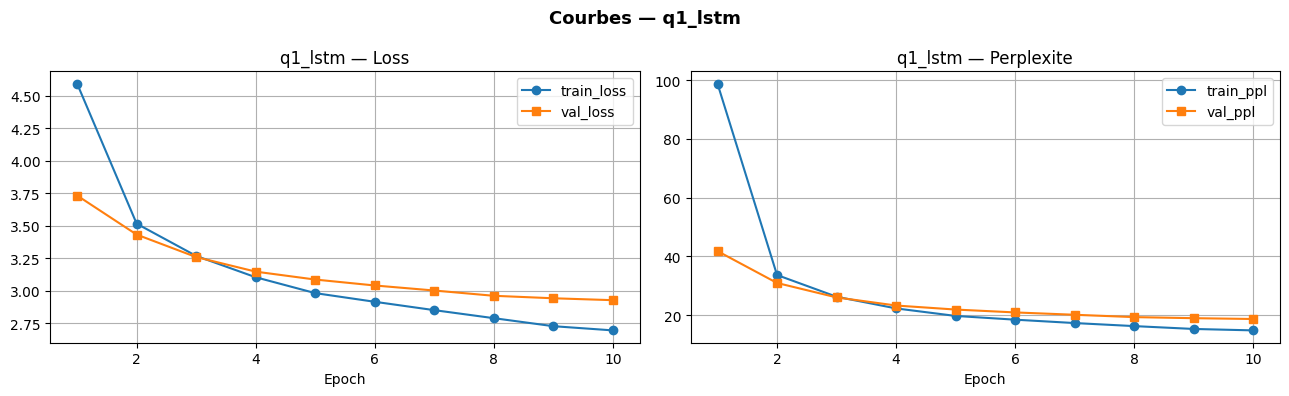

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q1_lstm_loss_curve.png


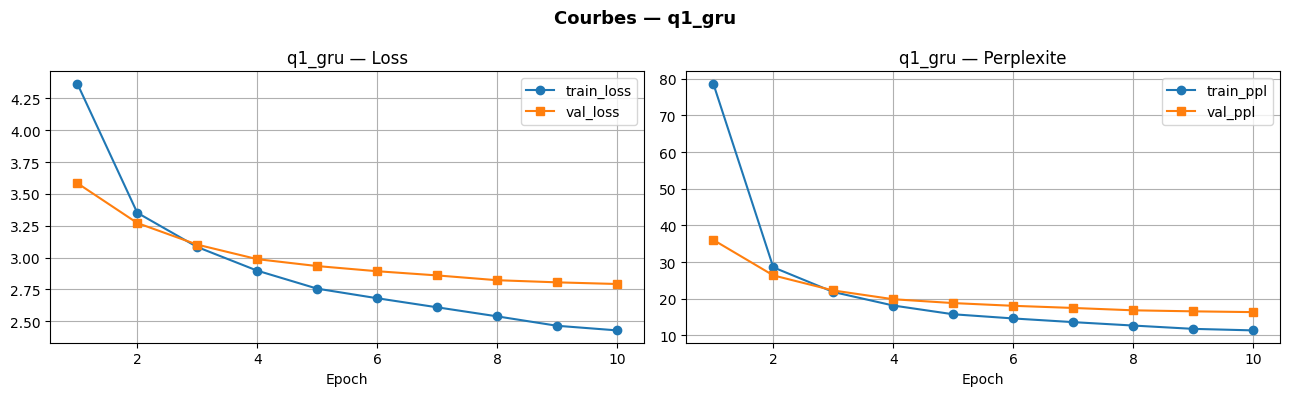

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q1_gru_loss_curve.png


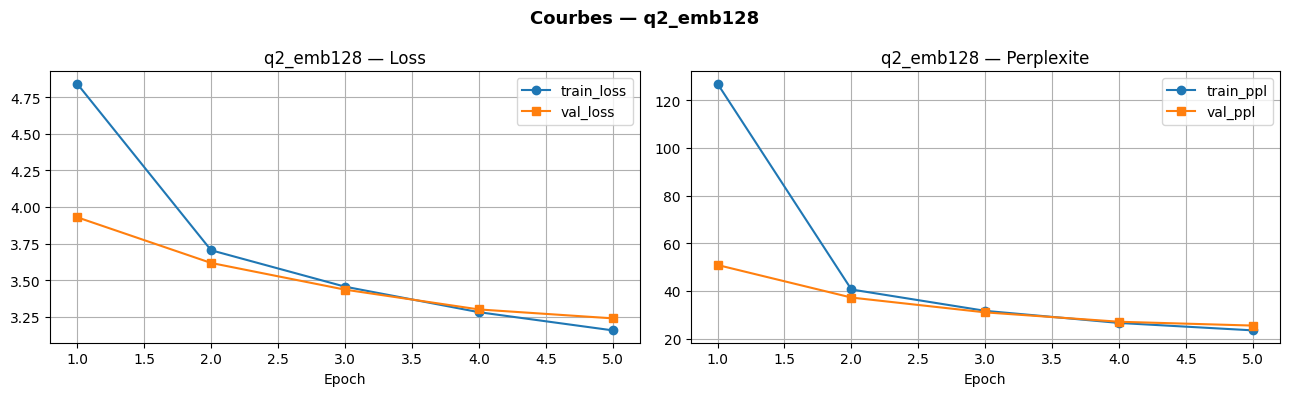

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q2_emb128_loss_curve.png


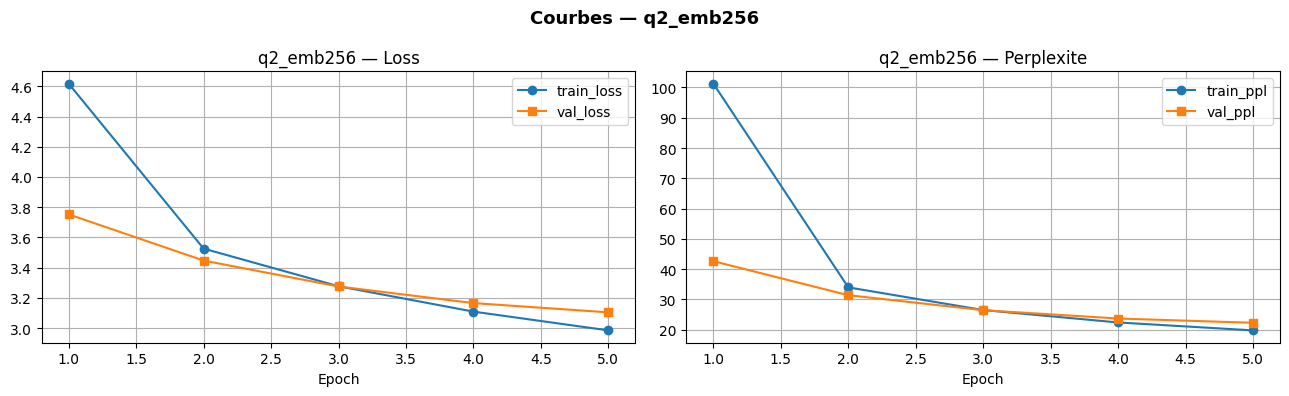

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q2_emb256_loss_curve.png


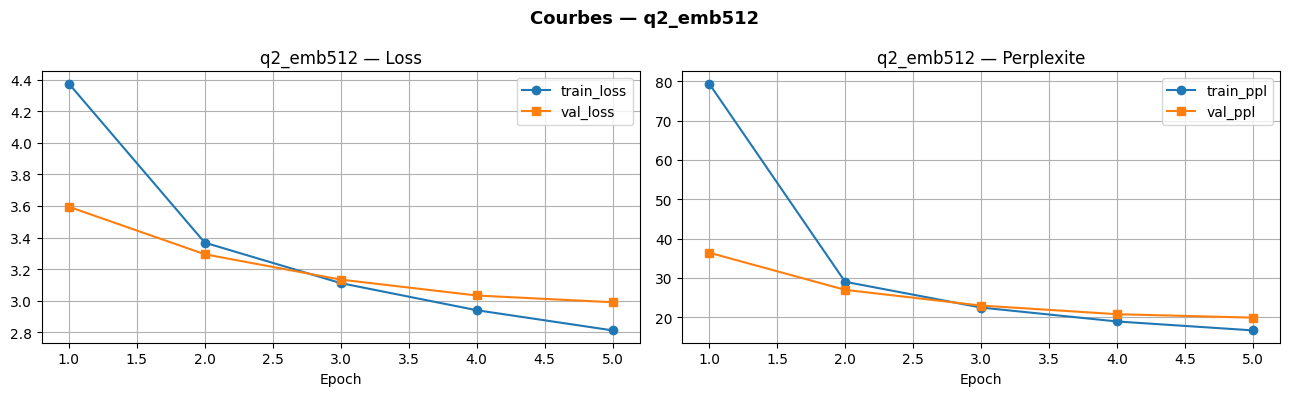

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q2_emb512_loss_curve.png


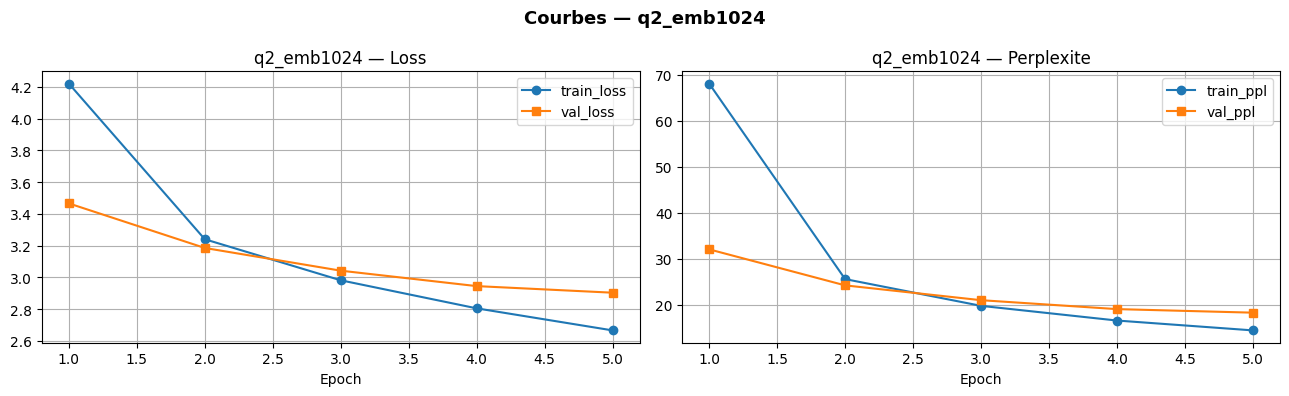

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q2_emb1024_loss_curve.png


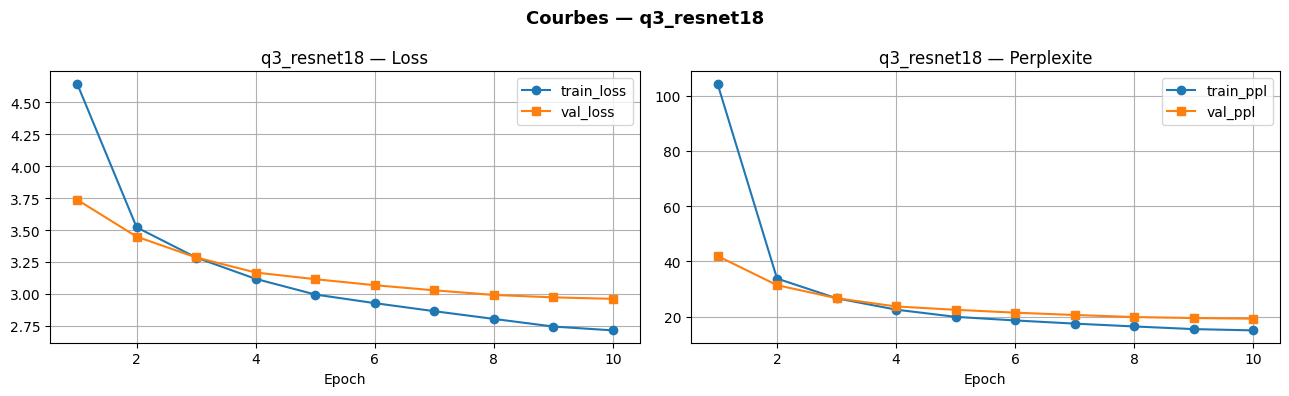

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q3_resnet18_loss_curve.png


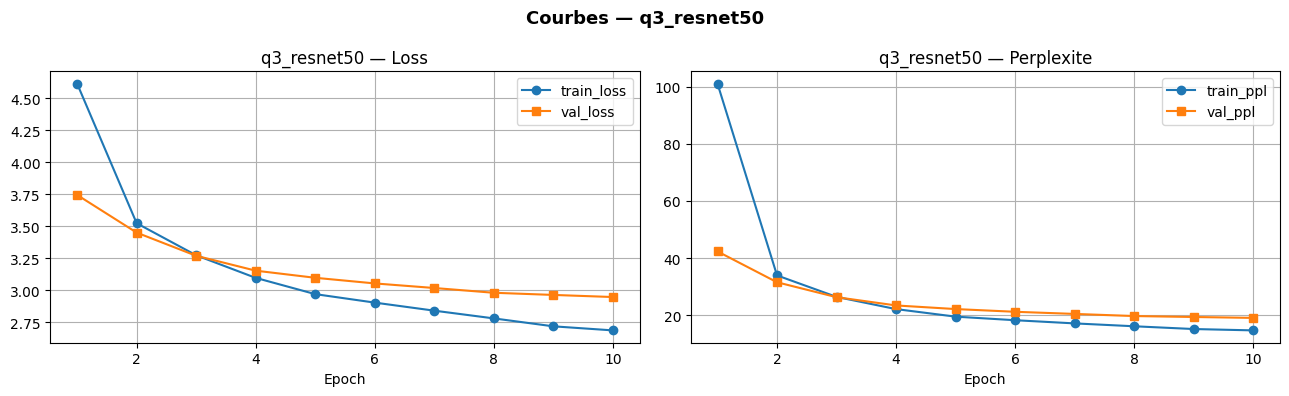

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q3_resnet50_loss_curve.png


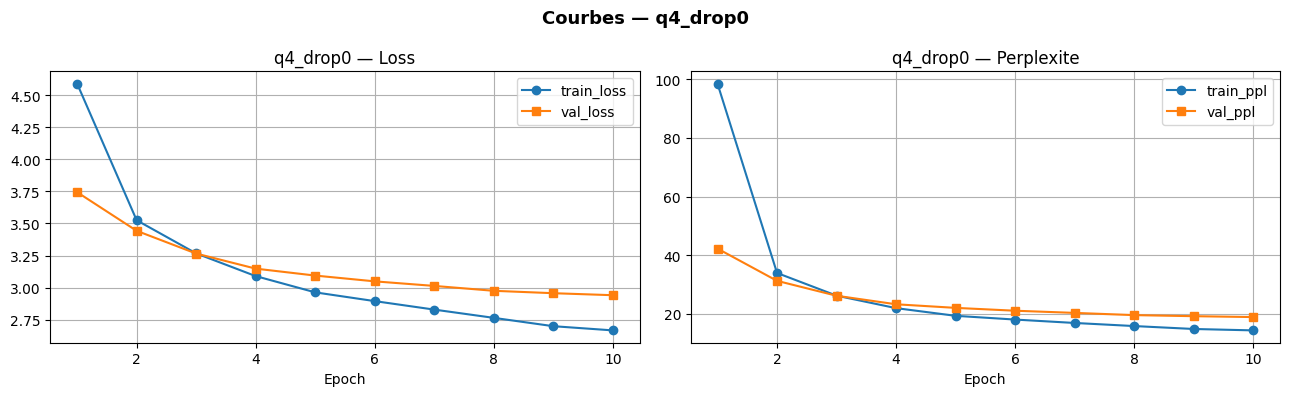

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q4_drop0_loss_curve.png


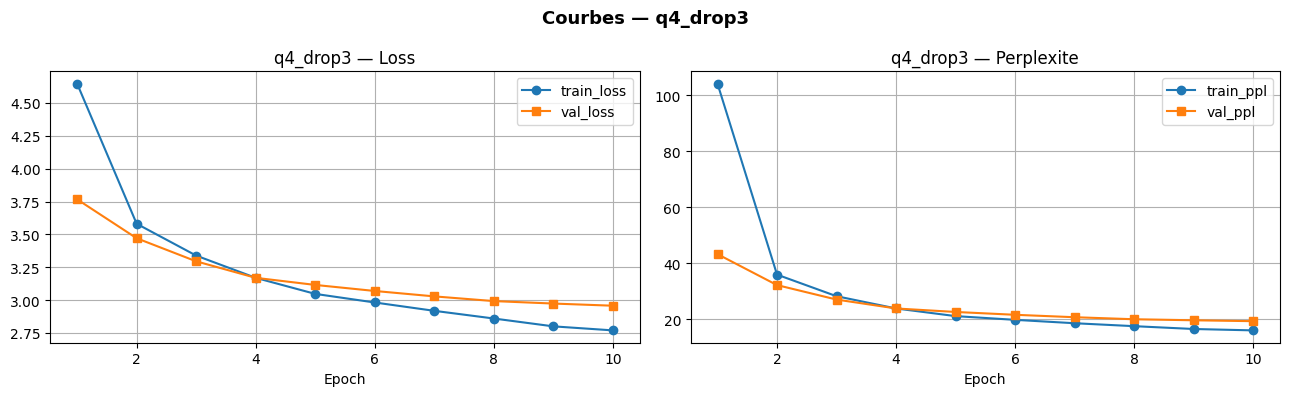

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q4_drop3_loss_curve.png


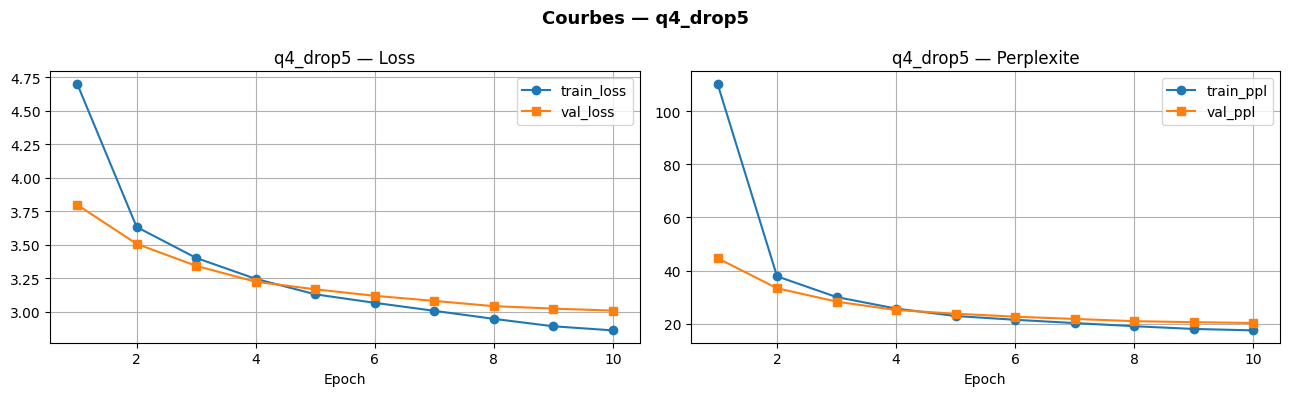

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q4_drop5_loss_curve.png


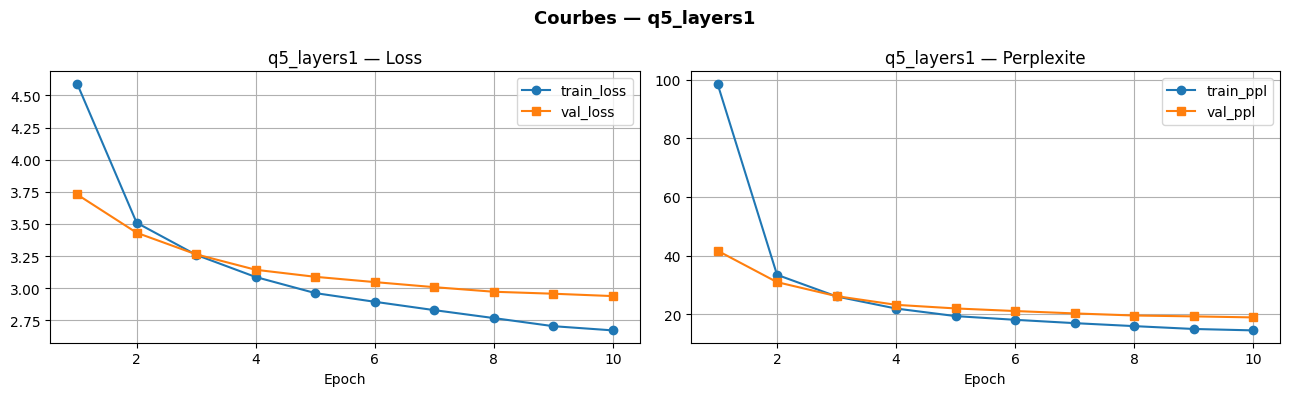

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q5_layers1_loss_curve.png


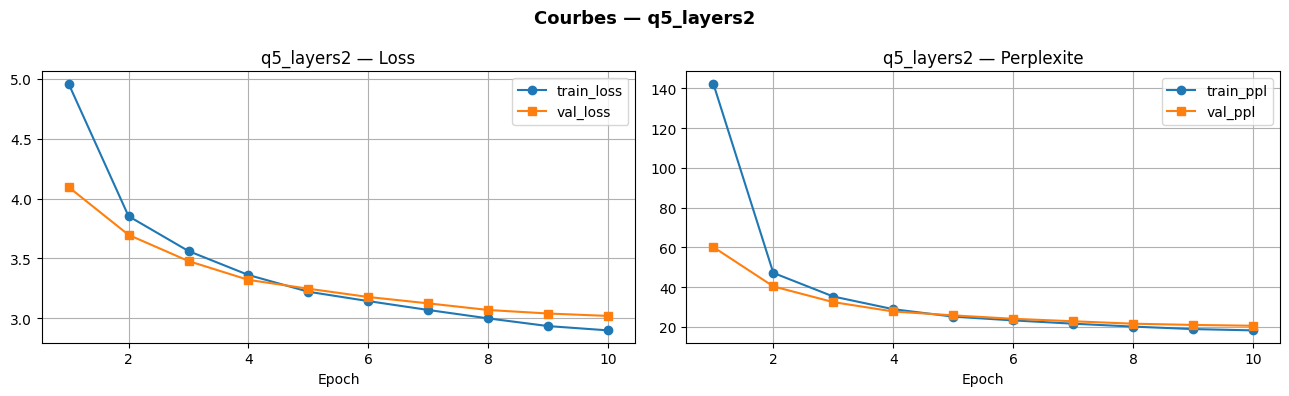

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q5_layers2_loss_curve.png


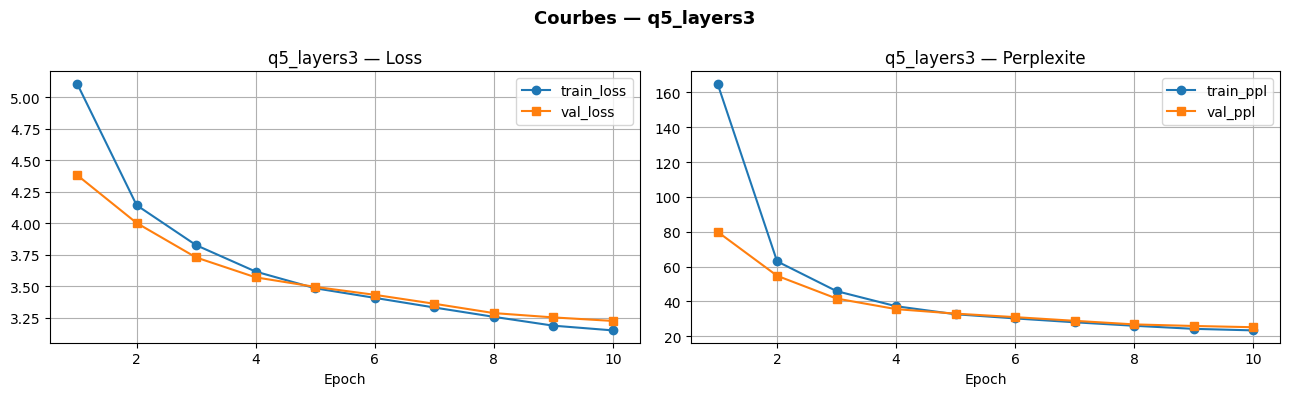

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q5_layers3_loss_curve.png


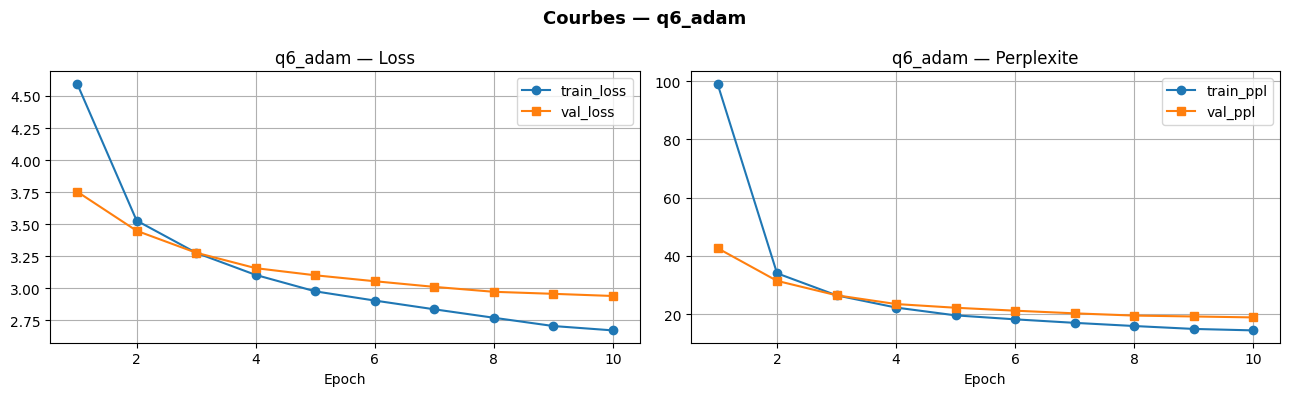

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q6_adam_loss_curve.png


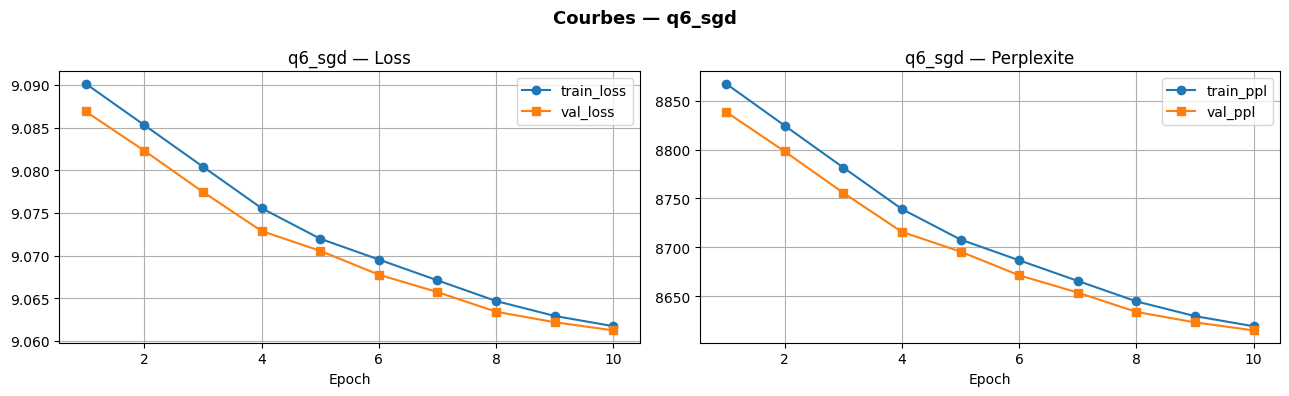

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/q6_sgd_loss_curve.png


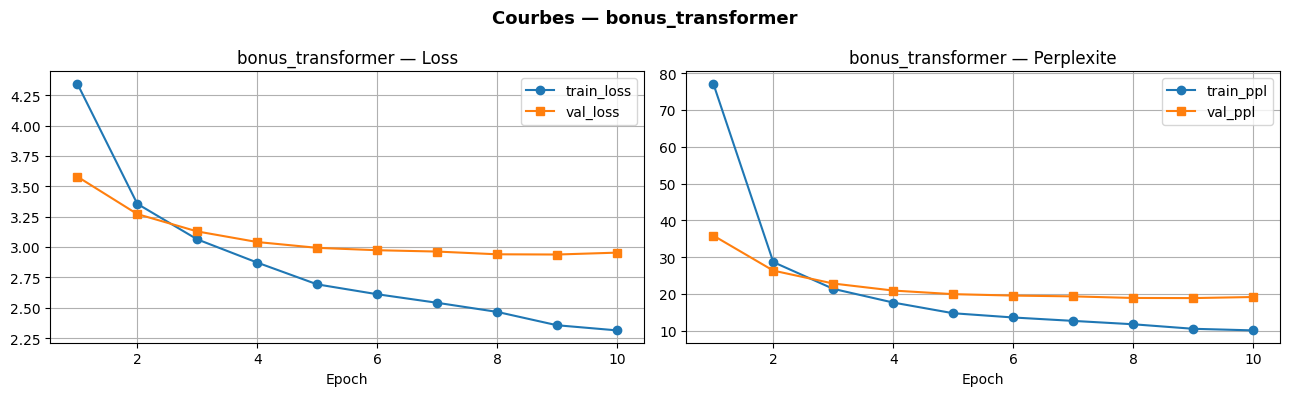

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/bonus_transformer_loss_curve.png


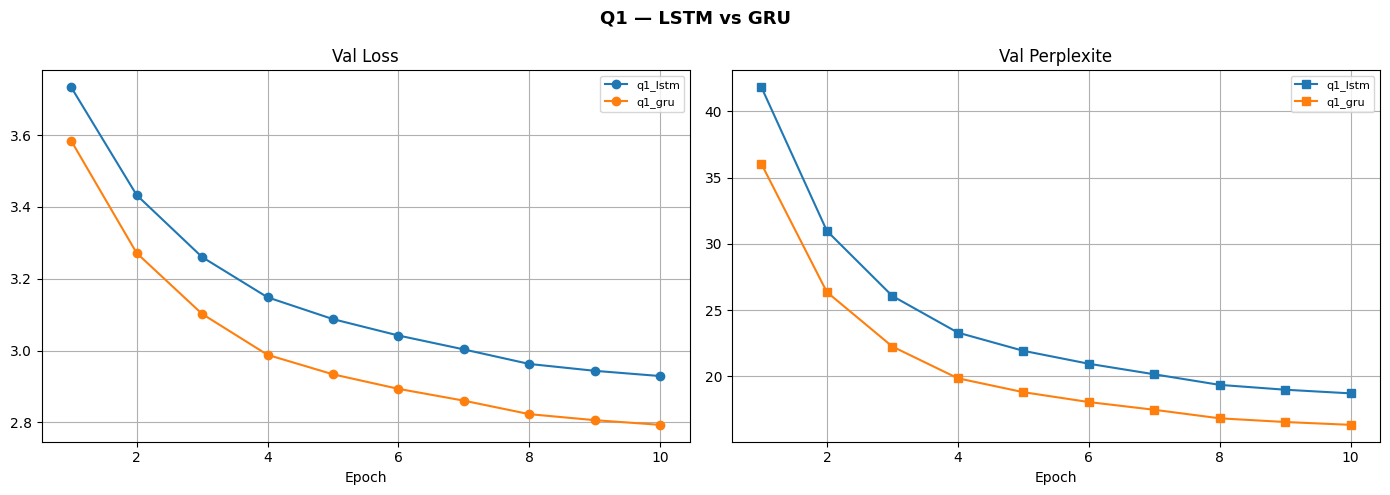

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/compare_q1.png


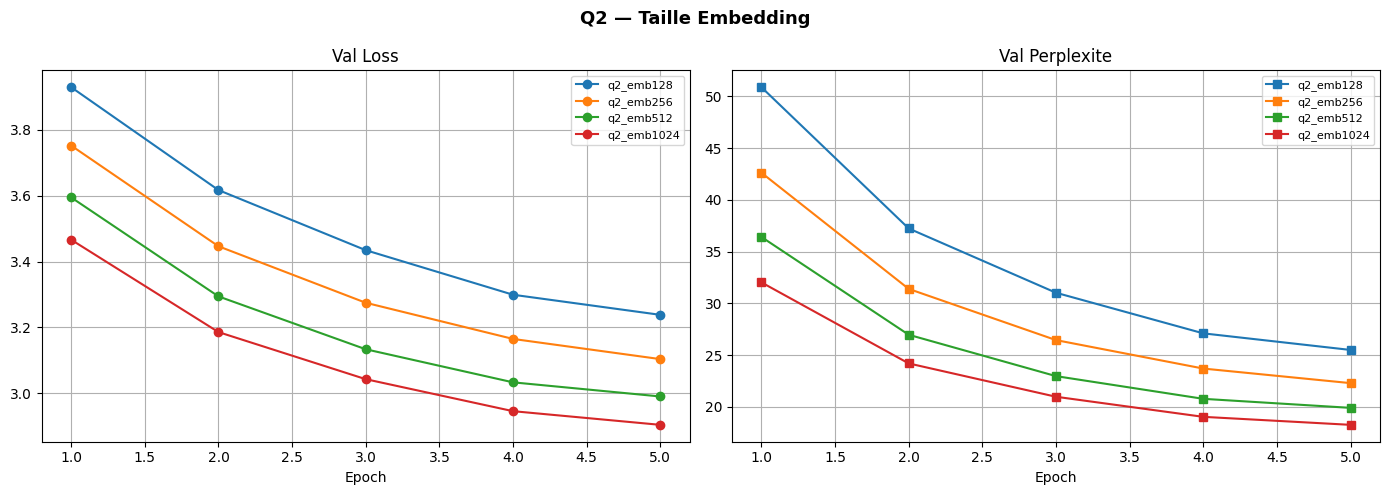

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/compare_q2.png


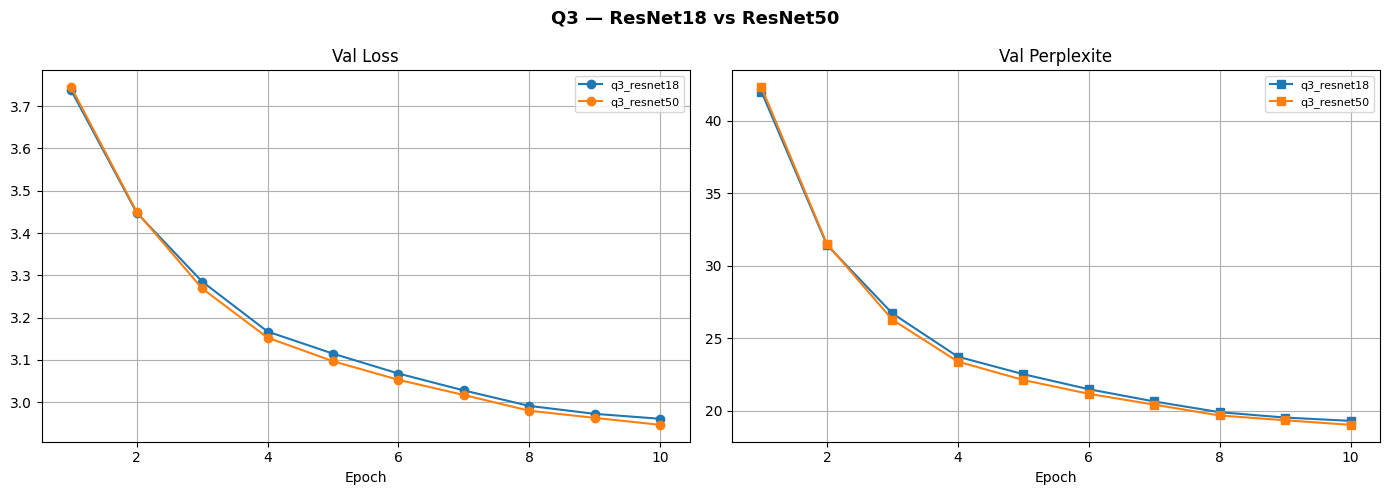

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/compare_q3.png


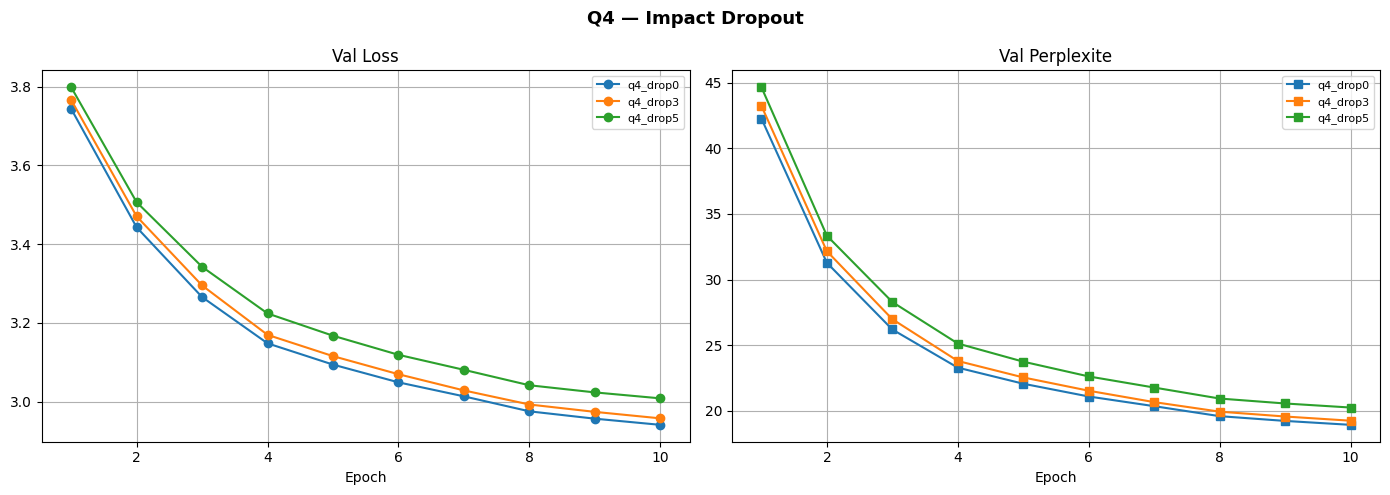

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/compare_q4.png


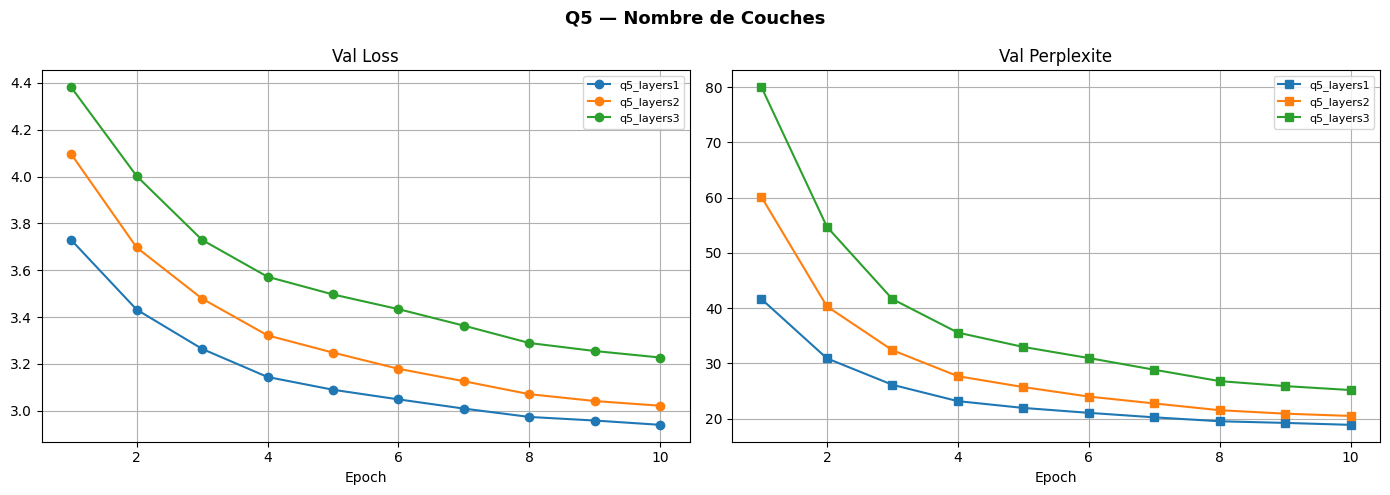

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/compare_q5.png


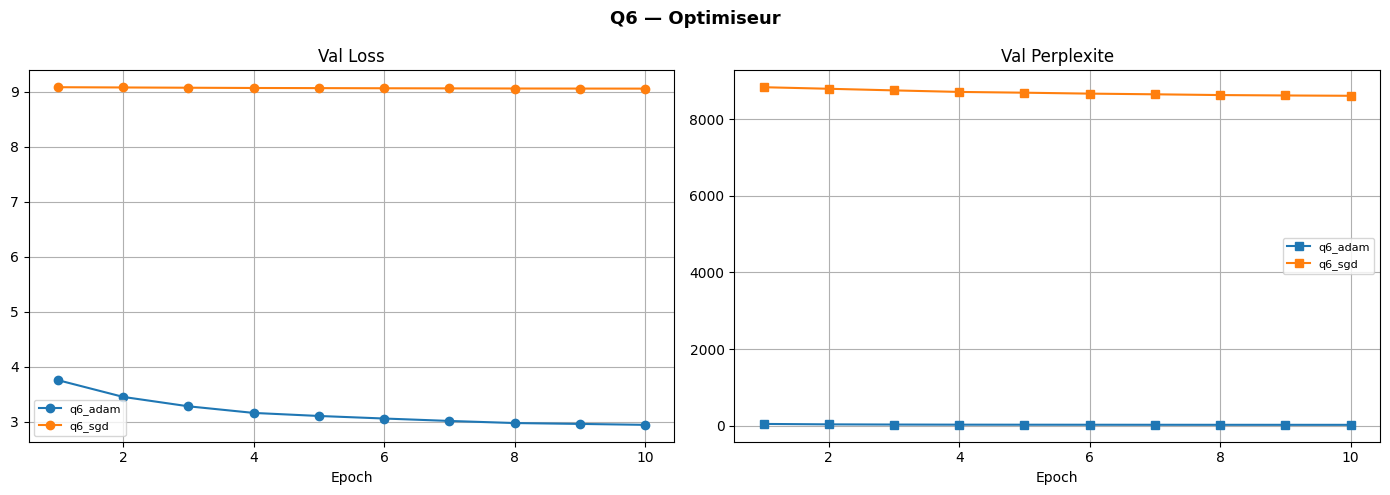

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/compare_q6.png


In [ ]:
# Courbes individuelles pour toutes les experiences
for tag, hist in all_histories.items():
    plot_loss(hist, tag)

# Comparaisons par groupe
compare_group(all_histories, 'q1', 'Q1 — LSTM vs GRU')
compare_group(all_histories, 'q2', 'Q2 — Taille Embedding')
compare_group(all_histories, 'q3', 'Q3 — ResNet18 vs ResNet50')
compare_group(all_histories, 'q4', 'Q4 — Impact Dropout')
compare_group(all_histories, 'q5', 'Q5 — Nombre de Couches')
compare_group(all_histories, 'q6', 'Q6 — Optimiseur')


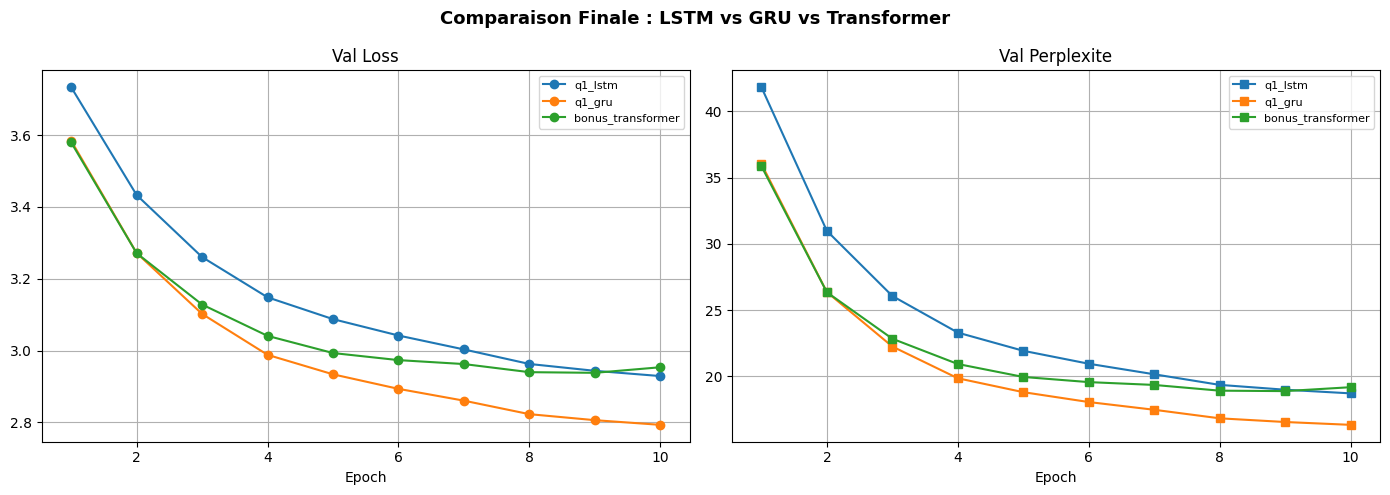

Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/plots/compare_final.png


In [ ]:
# Comparaison finale : LSTM vs GRU vs Transformer
final = {k: all_histories[k] for k in ['q1_lstm','q1_gru','bonus_transformer']
         if k in all_histories}
if final:
    compare_group(final, '', 'Comparaison Finale : LSTM vs GRU vs Transformer')


---
## 📋 Section 9 — Tableau Récapitulatif

In [ ]:
print(f"{'Experience':<25} {'Best Val Loss':>14} {'Best Val PPL':>13} {'Epochs':>7}")
print('─'*65)
rows = []
for tag, h in all_histories.items():
    bl = min(h['val_loss']); bp = min(h['val_ppl']); ep = len(h['val_loss'])
    print(f"  {tag:<23} {bl:>14.4f} {bp:>13.2f} {ep:>7}")
    rows.append((tag,bl,bp,ep))

summary_path = LOGS_DIR/'experiment_summary.txt'
with open(summary_path,'w') as f:
    f.write(f"{'Experience':<25} {'Best Val Loss':>14} {'Best Val PPL':>13} {'Epochs':>7}\n")
    f.write('─'*65+'\n')
    for tag,bl,bp,ep in rows:
        f.write(f"{tag:<25} {bl:>14.4f} {bp:>13.2f} {ep:>7}\n")

print(f"\nTableau sauvegarde -> {summary_path}")
if rows:
    best_tag = min(rows, key=lambda x:x[1])[0]
    print(f"Meilleure experience : {best_tag}  (val_loss={min(rows,key=lambda x:x[1])[1]:.4f})")


Experience                 Best Val Loss  Best Val PPL  Epochs
─────────────────────────────────────────────────────────────────
  q1_lstm                         2.9290         18.71      10
  q1_gru                          2.7932         16.33      10
  q2_emb128                       3.2383         25.49       5
  q2_emb256                       3.1038         22.28       5
  q2_emb512                       2.9903         19.89       5
  q2_emb1024                      2.9042         18.25       5
  q3_resnet18                     2.9606         19.31      10
  q3_resnet50                     2.9463         19.04      10
  q4_drop0                        2.9409         18.93      10
  q4_drop3                        2.9573         19.25      10
  q4_drop5                        3.0082         20.25      10
  q5_layers1                      2.9392         18.90      10
  q5_layers2                      3.0209         20.51      10
  q5_layers3                      3.2268         25.

---
## 🔍 Section 10 — Génération de Légendes & Inférence

In [ ]:
def ids_to_caption(ids):
    words = []
    for i in ids:
        w = idx2word.get(i,'')
        if w in ('endseq','<pad>'): break
        if w != 'startseq': words.append(w)
    return ' '.join(words)

@torch.no_grad()
def caption_image(image_path, encoder, decoder, rnn_type='lstm'):
    encoder.eval(); decoder.eval()
    img    = Image.open(image_path).convert('RGB')
    tensor = transform_test(img).unsqueeze(0).to(DEVICE)
    feat   = encoder(tensor)
    ids    = decoder.sample(feat) if rnn_type == 'transformer' else decoder.sample(feat.unsqueeze(1))
    return ids_to_caption(ids)

def evaluate_on_test(tag, epoch='best', rnn_type='lstm',
                     embed_size=256, hidden_size=512,
                     backbone='resnet50', num_layers=1,
                     dropout=0.0, n_samples=10):
    CNN = EncoderCNN(embed_size, backbone).to(DEVICE)
    RNN = (TransformerCaptionDecoder(embed_size, vocab_size, dropout=dropout).to(DEVICE)
           if rnn_type == 'transformer'
           else DecoderRNN(embed_size, hidden_size, vocab_size, num_layers, dropout, rnn_type).to(DEVICE))
    CNN, RNN = load_models_ckpt(CNN, RNN, epoch, tag)
    CNN.eval(); RNN.eval()
    test_list = list(test_imgs)[:n_samples]
    out_txt   = RESULTS_DIR/f'{tag}_generated_captions.txt'
    results   = []
    with open(out_txt,'w') as f_out:
        for img_name in tqdm(test_list, desc=f'Captions {tag}'):
            img_path = IMAGES_DIR/img_name
            caption  = caption_image(img_path, CNN, RNN, rnn_type)
            results.append((img_name, caption))
            f_out.write(f'{img_name}\t{caption}\n')
            img = Image.open(img_path).convert('RGB')
            fig,ax = plt.subplots(figsize=(6,4)); ax.imshow(img); ax.axis('off')
            ax.set_title(caption, fontsize=9, wrap=True,
                         bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.6))
            fig.tight_layout()
            fig.savefig(SAMPLES_DIR/f'{tag}_{Path(img_path).stem}.jpg', dpi=80, bbox_inches='tight')
            plt.show(); plt.close(fig)
    print(f"Captions sauvegardees -> {out_txt}")
    for n,c in results[:3]: print(f"  {n}: {c}")
    return results

print("Fonctions d'evaluation prete")


Fonctions d'evaluation prete


Captions q1_lstm:   0%|          | 0/10 [00:00<?, ?it/s]

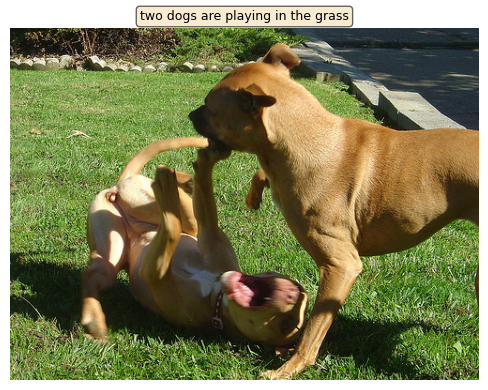

Captions q1_lstm:  10%|█         | 1/10 [00:00<00:03,  2.77it/s]

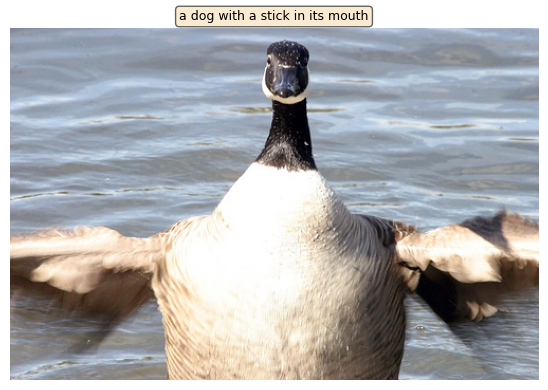

Captions q1_lstm:  20%|██        | 2/10 [00:00<00:02,  2.89it/s]

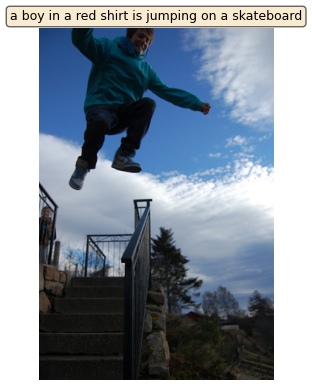

Captions q1_lstm:  30%|███       | 3/10 [00:00<00:02,  3.19it/s]

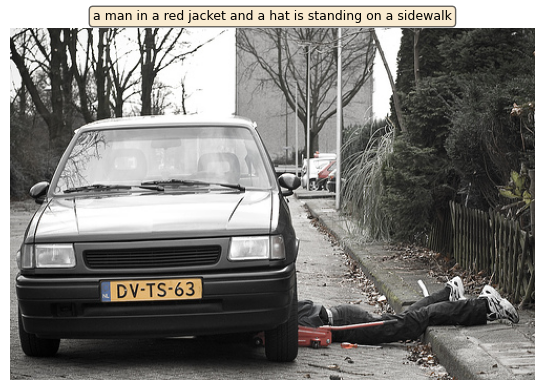

Captions q1_lstm:  40%|████      | 4/10 [00:01<00:02,  2.96it/s]

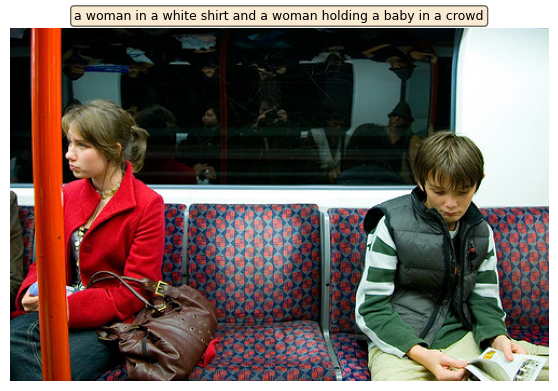

Captions q1_lstm:  50%|█████     | 5/10 [00:01<00:01,  2.61it/s]

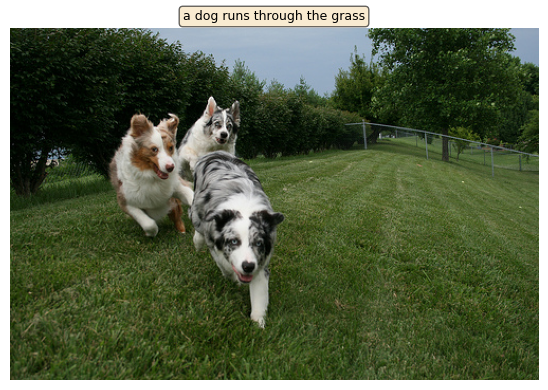

Captions q1_lstm:  60%|██████    | 6/10 [00:02<00:01,  2.75it/s]

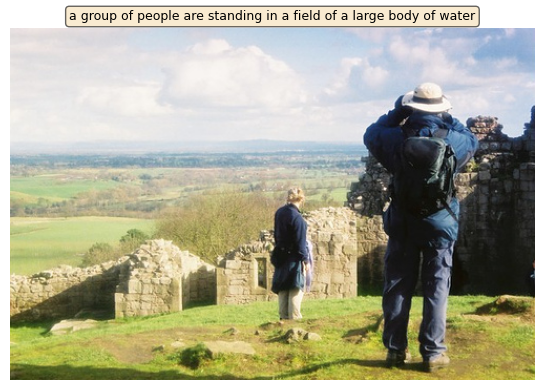

Captions q1_lstm:  70%|███████   | 7/10 [00:02<00:01,  2.48it/s]

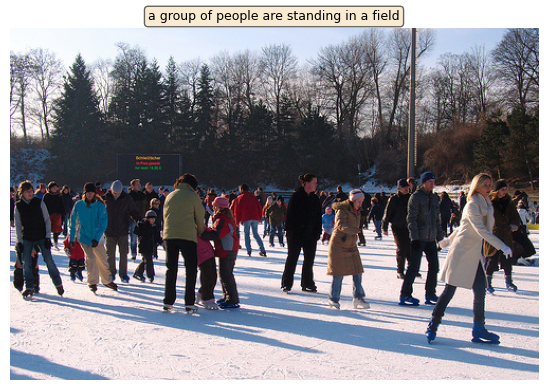

Captions q1_lstm:  80%|████████  | 8/10 [00:03<00:00,  2.50it/s]

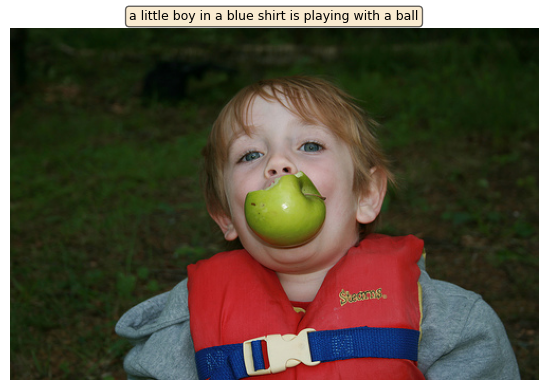

Captions q1_lstm:  90%|█████████ | 9/10 [00:03<00:00,  2.43it/s]

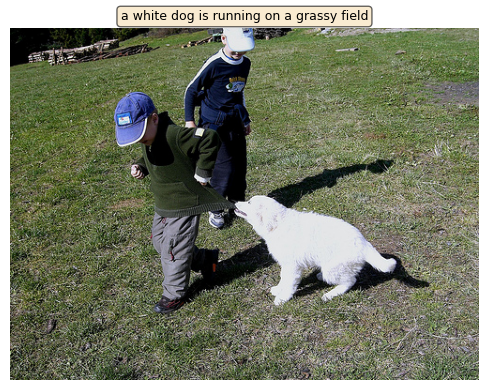

Captions q1_lstm: 100%|██████████| 10/10 [00:03<00:00,  2.60it/s]

Captions sauvegardees -> /content/drive/MyDrive/Flickr8k_Output/results/q1_lstm_generated_captions.txt
  252846811_7b250935a7.jpg: two dogs are playing in the grass
  358875403_f357f03713.jpg: a dog with a stick in its mouth
  3348811097_0e09baa26f.jpg: a boy in a red shirt is jumping on a skateboard


[('252846811_7b250935a7.jpg', 'two dogs are playing in the grass'),
 ('358875403_f357f03713.jpg', 'a dog with a stick in its mouth'),
 ('3348811097_0e09baa26f.jpg',
  'a boy in a red shirt is jumping on a skateboard'),
 ('2092870249_90e3f1855b.jpg',
  'a man in a red jacket and a hat is standing on a sidewalk'),
 ('295729735_8360f2e64c.jpg',
  'a woman in a white shirt and a woman holding a baby in a crowd'),
 ('3677927146_1696f0b075.jpg', 'a dog runs through the grass'),
 ('429283612_37f6e7fb7f.jpg',
  'a group of people are standing in a field of a large body of water'),
 ('3207343907_995f7ac1d2.jpg', 'a group of people are standing in a field'),
 ('3710674892_857b8056f7.jpg',
  'a little boy in a blue shirt is playing with a ball'),
 ('3122579598_14841c038a.jpg', 'a white dog is running on a grassy field')]

In [ ]:
# Generer les captions pour le meilleur modele
# Adapter tag, rnn_type, embed_size selon l'experience choisie
evaluate_on_test(
    tag='q1_lstm', epoch='best', rnn_type='lstm',
    embed_size=256, hidden_size=512, n_samples=10
)


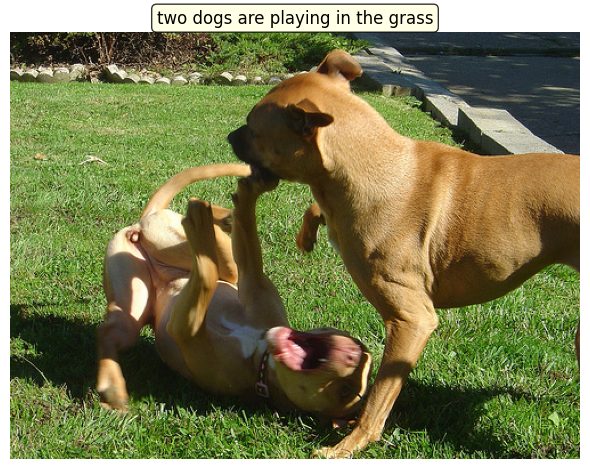

Caption : two dogs are playing in the grass
Sauvegarde -> /content/drive/MyDrive/Flickr8k_Output/results/inference_252846811_7b250935a7.jpg


In [ ]:
# Inference sur une image personnalisee
# Remplacez IMAGE_PATH par le chemin de votre image
IMAGE_PATH   = str(IMAGES_DIR / list(test_imgs)[0])
# IMAGE_PATH = '/content/drive/MyDrive/ma_photo.jpg'

INFER_TAG    = 'q1_lstm'
INFER_TYPE   = 'lstm'
EMBED_SIZE   = 256
HIDDEN_SIZE  = 512

CNN = EncoderCNN(EMBED_SIZE, 'resnet50').to(DEVICE)
RNN = DecoderRNN(EMBED_SIZE, HIDDEN_SIZE, vocab_size, rnn_type=INFER_TYPE).to(DEVICE)
CNN, RNN = load_models_ckpt(CNN, RNN, 'best', INFER_TAG)

caption = caption_image(IMAGE_PATH, CNN, RNN, INFER_TYPE)

img = Image.open(IMAGE_PATH).convert('RGB')
plt.figure(figsize=(6,5)); plt.imshow(img); plt.axis('off')
plt.title(f'{caption}', fontsize=12,
          bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.8))
plt.tight_layout()
out = RESULTS_DIR/f'inference_{Path(IMAGE_PATH).stem}.jpg'
plt.savefig(out, dpi=100, bbox_inches='tight'); plt.show()
print(f"Caption : {caption}")
print(f"Sauvegarde -> {out}")
